# Lab 5 - Case study 1: Decision Tree and Random Forest

### 1. Bài toán: Dự đoán nguy cơ mắc bệnh tiểu đường ở giai đoạn đầu sử dụng Decision Tree và Random Forest (60%)
Mục tiêu:
- Xây dựng mô hình Decision Tree và Random Forest sử dụng thư viện sklearn.
- Khảo sát và tối ưu mô hình bằng việc tìm kiếm các siêu tham số và lựa chọn đặc trưng.
- Áp dụng hai mô hình để giải quyết bài toán thực tế (Dự đoán nguy cơ mắc bệnh).
- Đánh giá chất lượng mô hình bằng độ đo thích hợp.

Dữ liệu:
- Thể hiện dưới dạng bảng, trong đó mỗi hàng tương ứng với một bệnh nhân, mỗi cột thể hiện các dấu hiệu và triệu chứng của bệnh nhân đó.
- Các trường thuộc tính tồn tại ở hai dạng: binary và numeric (continuous).
- Thuộc tính nhãn lớp 'class' cũng là một thuộc tính nhị phân (Positive/Negative).

Mô hình hóa bài toán: Bài toán phân loại nhị phân
- Đầu vào: N vector D chiều (ma trận cỡ N x D), tương ứng N cá thể với D thuộc tính.
- Đầu ra: Nhãn 1/(-1) (1: Positive, -1: Negative).

Nhiệm vụ:
- Thực hiện theo các yêu cầu bên dưới.
- Viết báo cáo trình bày, giải thích chi tiết các bước và nhận xét kết quả thu được.

### 2. Các bước thực hiện

#### 2.1. Import các thư viện cần thiết

In [1]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import matplotlib.pyplot as plt

#### 2.2. Tìm hiểu dữ liệu

In [2]:
''' Thông tin chi tiết về tập dữ liệu có thể xem tại trang web UCI
https://archive.ics.uci.edu/dataset/529/early+stage+diabetes+risk+prediction+dataset
'''
# Xem thông tin chi tiết
data = pd.read_csv('diabetes_data.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Age                 520 non-null    int64 
 1   Gender              520 non-null    object
 2   Polyuria            520 non-null    object
 3   Polydipsia          520 non-null    object
 4   sudden weight loss  520 non-null    object
 5   weakness            520 non-null    object
 6   Polyphagia          520 non-null    object
 7   Genital thrush      520 non-null    object
 8   visual blurring     520 non-null    object
 9   Itching             520 non-null    object
 10  Irritability        520 non-null    object
 11  delayed healing     520 non-null    object
 12  partial paresis     520 non-null    object
 13  muscle stiffness    520 non-null    object
 14  Alopecia            520 non-null    object
 15  Obesity             520 non-null    object
 16  class               520 no

In [3]:
data.isnull().sum() # Kiểm tra missing value

Age                   0
Gender                0
Polyuria              0
Polydipsia            0
sudden weight loss    0
weakness              0
Polyphagia            0
Genital thrush        0
visual blurring       0
Itching               0
Irritability          0
delayed healing       0
partial paresis       0
muscle stiffness      0
Alopecia              0
Obesity               0
class                 0
dtype: int64

In [4]:
# Mã hóa dữ liệu dạng category thành numeric
label_map = {'Negative' : -1, 'Positive': 1}
data['class'] = data['class'].map(label_map)
gender_map = {'Male': 1, 'Female': 0}
data['Gender'] = data['Gender'].map(gender_map)
other_map = {'Yes': 1, 'No': 0}
for col in data.columns:
    if col not in ['Age', 'Gender', 'class']:
        data[col] = data[col].map(other_map)

In [5]:
# Yêu cầu 1:
''' - Giải thích chức năng của đoạn code trên
    - Kết quả thu được sau khi chuẩn hóa là gì?

Trả lời:
- Đoạn code trên thực hiện mã hóa các thuộc tính dạng phân loại sang dạng số để mô hình Decision Tree và Random Forest có thể xử lý. Cụ thể, biến mục tiêu class được đổi từ Negative/Positive thành -1/1; Gender được đổi từ Female/Male thành 0/1; các thuộc tính triệu chứng dạng Yes/No được đổi thành 1/0.
- Sau bước mã hóa, toàn bộ các cột đầu vào và nhãn đều ở dạng số. Tập dữ liệu không còn giá trị chuỗi như Yes, No, Male, Female, Positive, Negative. Đây là bước tiền xử lý cần thiết trước khi chuẩn hóa Min-Max và huấn luyện mô hình học máy.
- Kết quả thu được giúp dữ liệu có cùng định dạng numeric, trong đó class = 1 biểu diễn bệnh nhân có nguy cơ/mắc bệnh tiểu đường và class = -1 biểu diễn trường hợp âm tính.
'''


' - Giải thích chức năng của đoạn code trên\n    - Kết quả thu được sau khi chuẩn hóa là gì?\n\nTrả lời:\n- Đoạn code trên thực hiện mã hóa các thuộc tính dạng phân loại sang dạng số để mô hình Decision Tree và Random Forest có thể xử lý. Cụ thể, biến mục tiêu class được đổi từ Negative/Positive thành -1/1; Gender được đổi từ Female/Male thành 0/1; các thuộc tính triệu chứng dạng Yes/No được đổi thành 1/0.\n- Sau bước mã hóa, toàn bộ các cột đầu vào và nhãn đều ở dạng số. Tập dữ liệu không còn giá trị chuỗi như Yes, No, Male, Female, Positive, Negative. Đây là bước tiền xử lý cần thiết trước khi chuẩn hóa Min-Max và huấn luyện mô hình học máy.\n- Kết quả thu được giúp dữ liệu có cùng định dạng numeric, trong đó class = 1 biểu diễn bệnh nhân có nguy cơ/mắc bệnh tiểu đường và class = -1 biểu diễn trường hợp âm tính.\n'

In [6]:
data.info() # Kiểm tra lại thông tin dữ liệu

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Age                 520 non-null    int64
 1   Gender              520 non-null    int64
 2   Polyuria            520 non-null    int64
 3   Polydipsia          520 non-null    int64
 4   sudden weight loss  520 non-null    int64
 5   weakness            520 non-null    int64
 6   Polyphagia          520 non-null    int64
 7   Genital thrush      520 non-null    int64
 8   visual blurring     520 non-null    int64
 9   Itching             520 non-null    int64
 10  Irritability        520 non-null    int64
 11  delayed healing     520 non-null    int64
 12  partial paresis     520 non-null    int64
 13  muscle stiffness    520 non-null    int64
 14  Alopecia            520 non-null    int64
 15  Obesity             520 non-null    int64
 16  class               520 non-null    int64
dt

##### Trực quan dữ liệu bệnh tiểu đường
Các biểu đồ dưới đây giúp quan sát phân bố nhãn, phân bố tuổi, tỷ lệ xuất hiện triệu chứng và tương quan giữa các thuộc tính trước khi huấn luyện mô hình.

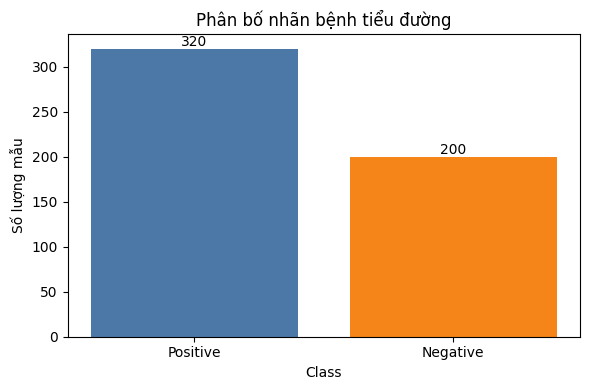

'\nNhận xét:\n- Biểu đồ cho biết dữ liệu có bao nhiêu mẫu Positive và Negative.\n- Nếu hai lớp chênh lệch nhiều, Accuracy có thể gây hiểu nhầm; vì vậy bài toán này dùng thêm Precision, Recall và F1-score để đánh giá mô hình.\n- Trong tập dữ liệu hiện tại, số mẫu Positive nhiều hơn Negative, nên cần chú ý khả năng mô hình dự đoán thiên về lớp dương tính.\n'

In [43]:
# Phân bố nhãn class
class_counts = data['class'].map({-1: 'Negative', 1: 'Positive'}).value_counts()

plt.figure(figsize=(6, 4))
plt.bar(class_counts.index, class_counts.values, color=['#4c78a8', '#f58518'])
plt.xlabel('Class')
plt.ylabel('Số lượng mẫu')
plt.title('Phân bố nhãn bệnh tiểu đường')
for i, value in enumerate(class_counts.values):
    plt.text(i, value + 3, str(value), ha='center')
plt.tight_layout()
plt.show()

'''
Nhận xét:
- Biểu đồ cho biết dữ liệu có bao nhiêu mẫu Positive và Negative.
- Nếu hai lớp chênh lệch nhiều, Accuracy có thể gây hiểu nhầm; vì vậy bài toán này dùng thêm Precision, Recall và F1-score để đánh giá mô hình.
- Trong tập dữ liệu hiện tại, số mẫu Positive nhiều hơn Negative, nên cần chú ý khả năng mô hình dự đoán thiên về lớp dương tính.
'''


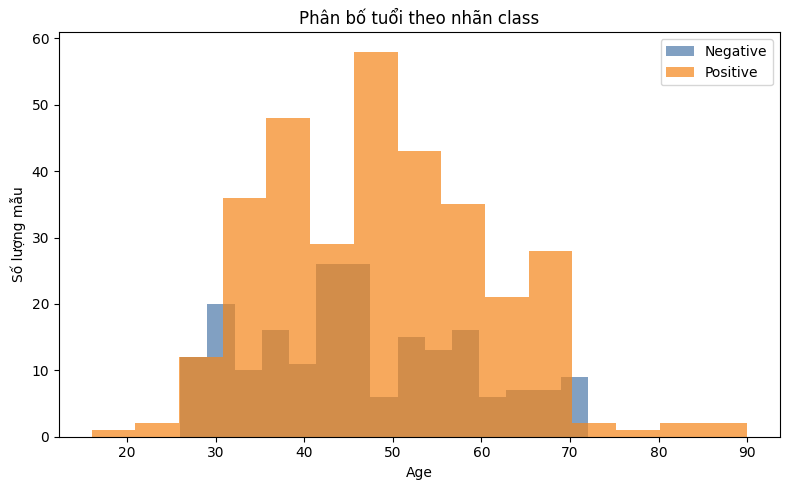

'\nNhận xét:\n- Biểu đồ histogram giúp so sánh độ tuổi giữa nhóm Positive và Negative.\n- Nếu một khoảng tuổi có nhiều mẫu Positive hơn, Age có thể hỗ trợ mô hình phân loại.\n- Tuy nhiên Age không nên được xem đơn lẻ; mô hình cây sẽ kết hợp Age với các triệu chứng khác để đưa ra dự đoán.\n'

In [44]:
# Phân bố tuổi theo từng lớp
positive_age = data.loc[data['class'] == 1, 'Age']
negative_age = data.loc[data['class'] == -1, 'Age']

plt.figure(figsize=(8, 5))
plt.hist(negative_age, bins=15, alpha=0.7, label='Negative', color='#4c78a8')
plt.hist(positive_age, bins=15, alpha=0.7, label='Positive', color='#f58518')
plt.xlabel('Age')
plt.ylabel('Số lượng mẫu')
plt.title('Phân bố tuổi theo nhãn class')
plt.legend()
plt.tight_layout()
plt.show()

'''
Nhận xét:
- Biểu đồ histogram giúp so sánh độ tuổi giữa nhóm Positive và Negative.
- Nếu một khoảng tuổi có nhiều mẫu Positive hơn, Age có thể hỗ trợ mô hình phân loại.
- Tuy nhiên Age không nên được xem đơn lẻ; mô hình cây sẽ kết hợp Age với các triệu chứng khác để đưa ra dự đoán.
'''


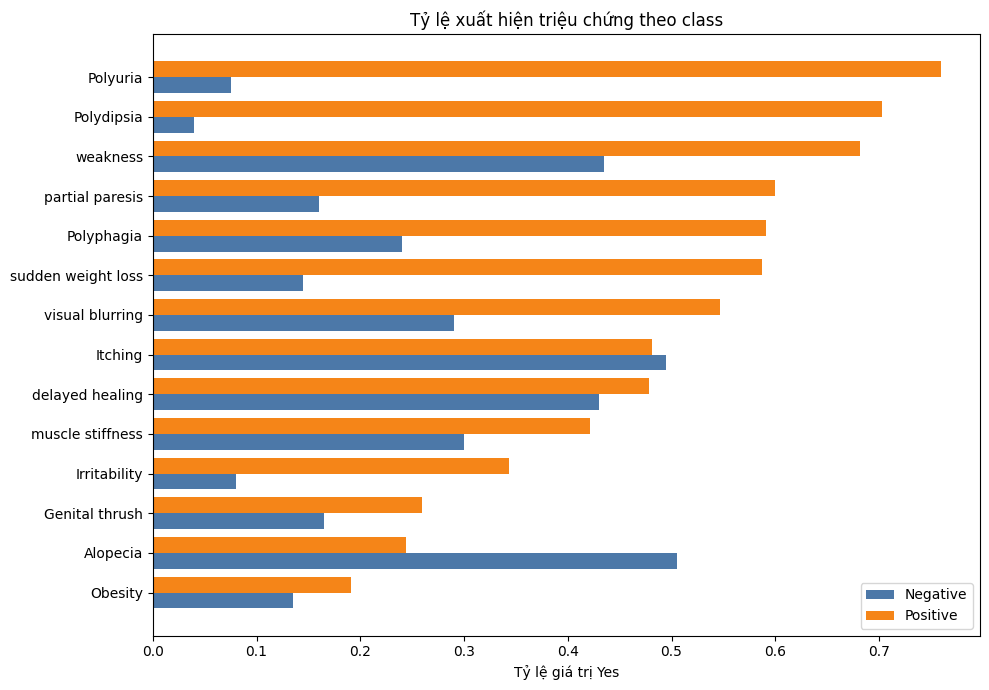

'\nNhận xét:\n- Vì các triệu chứng đã được mã hóa Yes = 1, No = 0 nên giá trị trung bình của mỗi cột chính là tỷ lệ xuất hiện triệu chứng.\n- Các triệu chứng có tỷ lệ cao ở nhóm Positive và thấp ở nhóm Negative thường là đặc trưng phân biệt tốt.\n- Những thuộc tính như Polyuria, Polydipsia, sudden weight loss có xu hướng liên quan mạnh đến lớp Positive, phù hợp với kết quả feature_importances_ ở phần mô hình.\n'

In [45]:
# Tỷ lệ xuất hiện từng triệu chứng theo nhãn class
symptom_cols = [col for col in data.columns if col not in ['Age', 'Gender', 'class']]
symptom_rate = data.groupby('class')[symptom_cols].mean().T
symptom_rate.columns = ['Negative', 'Positive']
symptom_rate = symptom_rate.sort_values('Positive', ascending=True)

plt.figure(figsize=(10, 7))
y_pos = np.arange(len(symptom_rate))
plt.barh(y_pos - 0.2, symptom_rate['Negative'], height=0.4, label='Negative', color='#4c78a8')
plt.barh(y_pos + 0.2, symptom_rate['Positive'], height=0.4, label='Positive', color='#f58518')
plt.yticks(y_pos, symptom_rate.index)
plt.xlabel('Tỷ lệ giá trị Yes')
plt.title('Tỷ lệ xuất hiện triệu chứng theo class')
plt.legend()
plt.tight_layout()
plt.show()

'''
Nhận xét:
- Vì các triệu chứng đã được mã hóa Yes = 1, No = 0 nên giá trị trung bình của mỗi cột chính là tỷ lệ xuất hiện triệu chứng.
- Các triệu chứng có tỷ lệ cao ở nhóm Positive và thấp ở nhóm Negative thường là đặc trưng phân biệt tốt.
- Những thuộc tính như Polyuria, Polydipsia, sudden weight loss có xu hướng liên quan mạnh đến lớp Positive, phù hợp với kết quả feature_importances_ ở phần mô hình.
'''


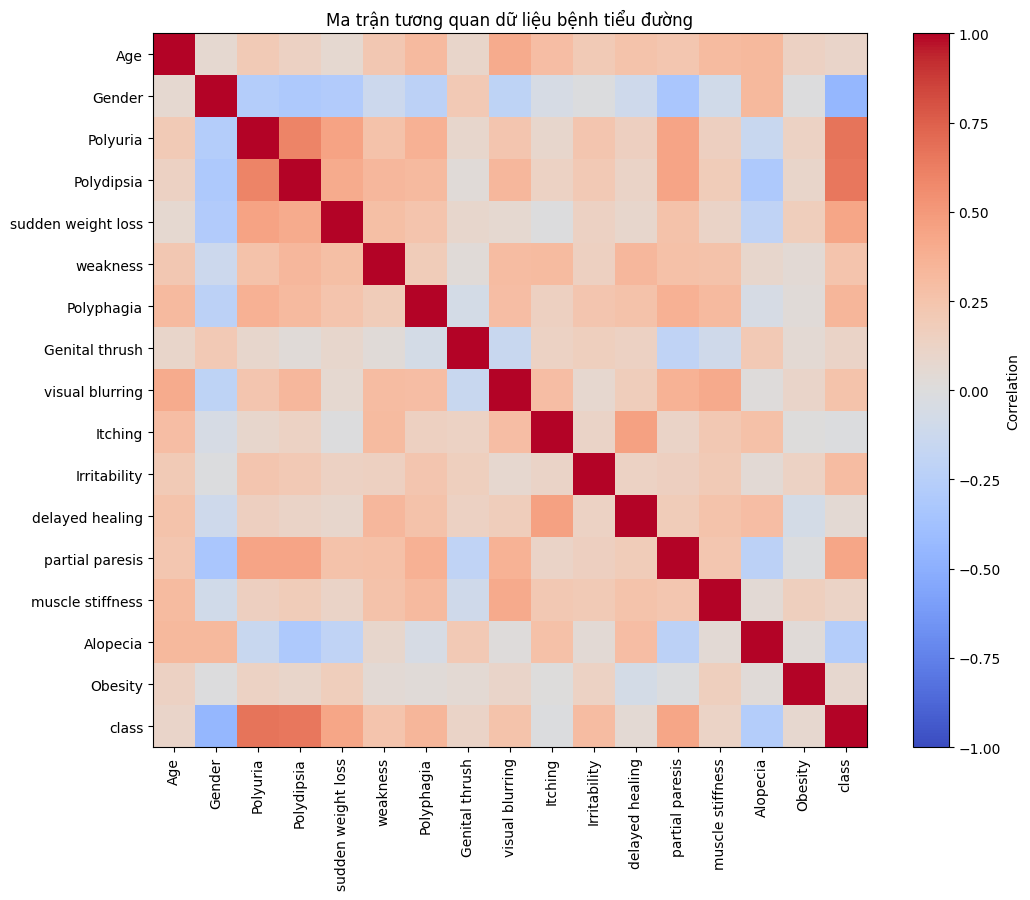

'\nNhận xét:\n- Ma trận tương quan giúp quan sát quan hệ tuyến tính giữa các thuộc tính và nhãn class.\n- Các ô có màu đậm thể hiện tương quan mạnh hơn. Thuộc tính có tương quan cao với class thường có khả năng đóng góp tốt cho mô hình.\n- Decision Tree và Random Forest không chỉ dựa vào tương quan tuyến tính; chúng còn học được các luật chia phi tuyến và tương tác giữa nhiều thuộc tính.\n'

In [46]:
# Ma trận tương quan giữa các thuộc tính numeric sau mã hóa
corr_matrix = data.corr(numeric_only=True)

plt.figure(figsize=(11, 9))
plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.title('Ma trận tương quan dữ liệu bệnh tiểu đường')
plt.tight_layout()
plt.show()

'''
Nhận xét:
- Ma trận tương quan giúp quan sát quan hệ tuyến tính giữa các thuộc tính và nhãn class.
- Các ô có màu đậm thể hiện tương quan mạnh hơn. Thuộc tính có tương quan cao với class thường có khả năng đóng góp tốt cho mô hình.
- Decision Tree và Random Forest không chỉ dựa vào tương quan tuyến tính; chúng còn học được các luật chia phi tuyến và tương tác giữa nhiều thuộc tính.
'''


In [7]:
# Yêu cầu 2: Chuẩn hóa dữ liệu
####
X = data.drop(columns=['class'])
y = data['class']
feature_names = X.columns.tolist()

scaler = MinMaxScaler()
X = scaler.fit_transform(X)

print('X shape:', X.shape)
print('y shape:', y.shape)
print('First sample after scaling:', X[0])
####

X shape: (520, 16)
y shape: (520,)
First sample after scaling: [0.32432432 1.         0.         1.         0.         1.
 0.         0.         0.         1.         0.         1.
 0.         1.         1.         1.        ]


In [8]:
# Yêu cầu 3: Chuẩn bị tập train-test cho mô hình học máy
####
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)
####

X_train: (416, 16)
X_test: (104, 16)
y_train: (416,)
y_test: (104,)


#### 2.3. Khởi tạo mô hình Decision Tree (DT) và Random Forest (RF) của sklearn

In [9]:
random_state = 42
DT = DecisionTreeClassifier(random_state=random_state)
RF = RandomForestClassifier(random_state=random_state)

In [10]:
# Yêu cầu 4: Chạy DT baseline
''' - Huấn luyện mô hình DT vừa khởi tạo với tập Train
    - Đánh giá mô hình DT đã huấn luyện với tập Test
    - In ra giá trị các độ đo: Accuracy, Precision, Recall, F1-Score, Ma trận nhầm lẫn (Có thể sử dụng thư viện sklearn hoặc viết tay)
    - Giải thích các kết quả trong ma trận nhầm lẫn

Giải thích code và kết quả:
- DT.fit(X_train, y_train) huấn luyện mô hình Decision Tree trên tập train; DT.predict(X_test) dự đoán nhãn cho tập test.
- accuracy_score, precision_score, recall_score và f1_score lần lượt đo độ chính xác tổng thể, độ chính xác của các mẫu dự đoán dương tính, khả năng phát hiện mẫu dương tính thật và trung bình điều hòa giữa precision/recall.
- Ma trận nhầm lẫn của DT là [[40, 0], [1, 63]]. Theo thứ tự nhãn [-1, 1]: có 40 mẫu âm tính được dự đoán đúng, 0 mẫu âm tính bị dự đoán nhầm thành dương tính, 1 mẫu dương tính bị dự đoán nhầm thành âm tính và 63 mẫu dương tính được dự đoán đúng.
- Accuracy = 0.9904 và F1-score = 0.9921 cho thấy mô hình baseline hoạt động rất tốt trên tập test. Precision = 1.0 nghĩa là các mẫu được DT dự đoán dương tính đều đúng; Recall = 0.9844 nghĩa là mô hình bỏ sót 1/64 mẫu dương tính.
'''
####
print('Demo DT prediction')
DT.fit(X_train, y_train)
dt_pred = DT.predict(X_test)

print('Accuracy:', accuracy_score(y_test, dt_pred))
print('Precision:', precision_score(y_test, dt_pred))
print('Recall:', recall_score(y_test, dt_pred))
print('F1-Score:', f1_score(y_test, dt_pred))
print('Confusion matrix:')
print(confusion_matrix(y_test, dt_pred))
print(classification_report(y_test, dt_pred))
####


Demo DT prediction
Accuracy: 0.9903846153846154
Precision: 1.0
Recall: 0.984375
F1-Score: 0.9921259842519685
Confusion matrix:
[[40  0]
 [ 1 63]]
              precision    recall  f1-score   support

          -1       0.98      1.00      0.99        40
           1       1.00      0.98      0.99        64

    accuracy                           0.99       104
   macro avg       0.99      0.99      0.99       104
weighted avg       0.99      0.99      0.99       104



In [11]:
# Yêu cầu 5: Chạy RF baseline
''' - Huấn luyện mô hình RF vừa khởi tạo với tập Train
    - Đánh giá mô hình RF đã huấn luyện với tập Test
    - In ra giá trị các độ đo: Accuracy, Precision, Recall, F1-Score, Ma trận nhầm lẫn (Có thể sử dụng thư viện sklearn hoặc viết tay)
    - Giải thích các kết quả trong ma trận nhầm lẫn

Giải thích code và kết quả:
- RF.fit(X_train, y_train) huấn luyện Random Forest trên tập train. Random Forest kết hợp nhiều cây quyết định, sau đó lấy biểu quyết số đông để đưa ra dự đoán cuối cùng.
- RF.predict(X_test) tạo dự đoán trên tập test; các hàm metric được dùng để đánh giá chất lượng dự đoán tương tự phần Decision Tree.
- Ma trận nhầm lẫn của RF là [[39, 1], [1, 63]]. Theo thứ tự nhãn [-1, 1]: có 39 mẫu âm tính đúng, 1 mẫu âm tính bị dự đoán nhầm thành dương tính, 1 mẫu dương tính bị bỏ sót và 63 mẫu dương tính đúng.
- Accuracy = 0.9808, Precision = Recall = F1-score = 0.9844. Kết quả này vẫn rất cao, nhưng thấp hơn DT baseline một chút trên lần chia train-test hiện tại vì RF sai 2 mẫu trong khi DT sai 1 mẫu.
'''
####
print('Demo RF prediction')
RF.fit(X_train, y_train)
rf_pred = RF.predict(X_test)

print('Accuracy:', accuracy_score(y_test, rf_pred))
print('Precision:', precision_score(y_test, rf_pred))
print('Recall:', recall_score(y_test, rf_pred))
print('F1-Score:', f1_score(y_test, rf_pred))
print('Confusion matrix:')
print(confusion_matrix(y_test, rf_pred))
print(classification_report(y_test, rf_pred))
####


Demo RF prediction
Accuracy: 0.9807692307692307
Precision: 0.984375
Recall: 0.984375
F1-Score: 0.984375
Confusion matrix:
[[39  1]
 [ 1 63]]
              precision    recall  f1-score   support

          -1       0.97      0.97      0.97        40
           1       0.98      0.98      0.98        64

    accuracy                           0.98       104
   macro avg       0.98      0.98      0.98       104
weighted avg       0.98      0.98      0.98       104



#### 2.4. Tìm kiếm siêu tham số

In [12]:
# Sử dụng kỹ thuật grid_search
def grid_search(algorithm, X_train, y_train, n_jobs, dict_param):
    if algorithm == 'decision-tree':
        model = DecisionTreeClassifier()
    if algorithm == 'random-forest':
        model = RandomForestClassifier()
    classifier = GridSearchCV(estimator=model, cv=5, param_grid=dict_param,n_jobs=n_jobs, scoring='f1')
    classifier.fit(X_train, y_train)
    print('Best model', end='')
    print(classifier.best_estimator_)
    print("Best parameters:", classifier.best_params_)
    return classifier.best_estimator_

# Sử dụng kỹ thuật random_search
def random_search(algorithm, X_train, y_train, n_jobs, dict_param, n_iter=20):
    if algorithm == 'decision-tree':
        model = DecisionTreeClassifier(random_state=random_state)
    if algorithm == 'random-forest':
        model = RandomForestClassifier(random_state=random_state)

    classifier = RandomizedSearchCV(
        estimator=model,
        param_distributions=dict_param,
        n_iter=n_iter,
        cv=5,
        n_jobs=n_jobs,
        scoring='f1',
        random_state=random_state
    )
    classifier.fit(X_train, y_train)
    print('Best model', end='')
    print(classifier.best_estimator_)
    print('Best parameters:', classifier.best_params_)
    print('Best CV F1-score:', classifier.best_score_)
    return classifier.best_estimator_

# Đánh giá hiệu suất
def evaluate(X_train, y_train, X_test, y_test, model):
    print("Train Accuracy:", accuracy_score(y_train, model.predict(X_train)))
    print("Train Precision: ", precision_score(y_train, model.predict(X_train)))
    print("Train Recall: ", recall_score(y_train, model.predict(X_train)))
    print("Train F1-score:", f1_score(y_train, model.predict(X_train)))
    print("Train Confusion Matrix:")
    print(confusion_matrix(y_train, model.predict(X_train)))
    print("-"*50)
    print("Test Accuracy:", accuracy_score(y_test, model.predict(X_test)))
    print("Test Precision:", precision_score(y_test, model.predict(X_test)))
    print("Test Recall: ", recall_score(y_test, model.predict(X_test)))
    print("Test F1-score:", f1_score(y_test, model.predict(X_test)))
    print("Test Confusion Matrix:")
    print(confusion_matrix(y_test, model.predict(X_test)))
    return f1_score(y_train, model.predict(X_train)), f1_score(y_test, model.predict(X_test))

In [13]:
# Yêu cầu 6:
''' Giải thích chức năng của hàm grid_search, random_search và evaluate

Trả lời:
- Hàm grid_search nhận loại thuật toán, dữ liệu train, số luồng xử lý n_jobs và lưới siêu tham số dict_param. Tùy theo algorithm, hàm khởi tạo DecisionTreeClassifier hoặc RandomForestClassifier.
- GridSearchCV thử toàn bộ các tổ hợp siêu tham số trong dict_param, đánh giá bằng 5-fold cross-validation và dùng F1-score làm tiêu chí chọn mô hình tốt nhất. Cách này có tính hệ thống nhưng tốn thời gian khi không gian tham số lớn.
- Hàm random_search cũng nhận các đầu vào tương tự nhưng dùng RandomizedSearchCV. Thay vì thử toàn bộ tổ hợp, hàm chỉ lấy ngẫu nhiên n_iter tổ hợp siêu tham số để đánh giá bằng cross-validation. Cách này giúp khảo sát nhanh hơn và phù hợp khi có nhiều siêu tham số.
- Hàm evaluate nhận tập train, tập test và mô hình đã huấn luyện. Hàm in các độ đo Accuracy, Precision, Recall, F1-score và confusion matrix trên cả train và test.
- Việc in đồng thời kết quả train/test giúp so sánh khả năng học và khả năng tổng quát hóa của mô hình. Nếu train rất cao nhưng test thấp hơn nhiều thì có dấu hiệu overfitting.
'''


' Giải thích chức năng của hàm grid_search, random_search và evaluate\n\nTrả lời:\n- Hàm grid_search nhận loại thuật toán, dữ liệu train, số luồng xử lý n_jobs và lưới siêu tham số dict_param. Tùy theo algorithm, hàm khởi tạo DecisionTreeClassifier hoặc RandomForestClassifier.\n- GridSearchCV thử toàn bộ các tổ hợp siêu tham số trong dict_param, đánh giá bằng 5-fold cross-validation và dùng F1-score làm tiêu chí chọn mô hình tốt nhất. Cách này có tính hệ thống nhưng tốn thời gian khi không gian tham số lớn.\n- Hàm random_search cũng nhận các đầu vào tương tự nhưng dùng RandomizedSearchCV. Thay vì thử toàn bộ tổ hợp, hàm chỉ lấy ngẫu nhiên n_iter tổ hợp siêu tham số để đánh giá bằng cross-validation. Cách này giúp khảo sát nhanh hơn và phù hợp khi có nhiều siêu tham số.\n- Hàm evaluate nhận tập train, tập test và mô hình đã huấn luyện. Hàm in các độ đo Accuracy, Precision, Recall, F1-score và confusion matrix trên cả train và test.\n- Việc in đồng thời kết quả train/test giúp so sánh kh

##### 2.4.1. Decision Tree (DT)

##### Trước hết, hãy thử khảo sát DT với siêu tham số: max_depth (độ sâu của cây)

Text(0.5, 1.0, 'DT validation curve for max_depth')

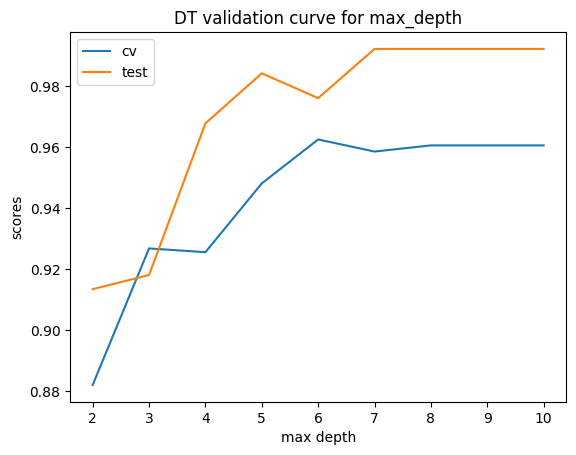

In [14]:
cv_accuracies_by_depth, test_accuracies_by_depth= [], []
max_depth_values= np.arange(2,11)

for curr_max_depth in max_depth_values:
  tree= DecisionTreeClassifier(random_state=random_state, max_depth=curr_max_depth)

  # cross-validation
  val_scores= cross_val_score(estimator=tree, X=X_train, y=y_train, cv=5, scoring='f1')
  cv_accuracies_by_depth.append(val_scores.mean())

  # test
  tree.fit(X_train, y_train)
  curr_pred= tree.predict(X_test)
  test_accuracies_by_depth.append(f1_score(curr_pred, y_test))

# Plot
plt.plot(max_depth_values, cv_accuracies_by_depth, label='cv')
plt.plot(max_depth_values, test_accuracies_by_depth, label='test')
plt.legend()
plt.xlabel('max depth')
plt.ylabel('scores')
plt.title('DT validation curve for max_depth')

In [15]:
# Yêu cầu 7:
''' - Giải thích chức năng của đoạn code trên
    - Nhận xét biểu đồ thu được

Trả lời:
- Đoạn code khảo sát ảnh hưởng của siêu tham số max_depth đối với Decision Tree. Với từng giá trị max_depth từ 2 đến 10, mô hình được đánh giá bằng 5-fold cross-validation trên tập train và sau đó được kiểm tra trên tập test.
- cross_val_score(..., scoring='f1') dùng F1-score trung bình của 5 fold để ước lượng hiệu suất ổn định hơn trên tập train. Sau đó mô hình được fit lại trên toàn bộ X_train và tính F1-score trên X_test.
- Biểu đồ validation curve so sánh đường điểm cv và test theo max_depth. Nếu max_depth quá nhỏ, cây bị giới hạn độ phức tạp nên có thể underfit. Khi max_depth tăng, điểm số thường tăng đến một mức ổn định; nếu train/cv cao nhưng test giảm thì có dấu hiệu overfitting.
- Trong kết quả hiện tại, các giá trị max_depth nhỏ đến trung bình đã cho điểm khá tốt. Vì vậy cần dùng GridSearchCV để chọn max_depth kết hợp với các siêu tham số khác thay vì chỉ chọn theo một biểu đồ đơn lẻ.
'''


" - Giải thích chức năng của đoạn code trên\n    - Nhận xét biểu đồ thu được\n\nTrả lời:\n- Đoạn code khảo sát ảnh hưởng của siêu tham số max_depth đối với Decision Tree. Với từng giá trị max_depth từ 2 đến 10, mô hình được đánh giá bằng 5-fold cross-validation trên tập train và sau đó được kiểm tra trên tập test.\n- cross_val_score(..., scoring='f1') dùng F1-score trung bình của 5 fold để ước lượng hiệu suất ổn định hơn trên tập train. Sau đó mô hình được fit lại trên toàn bộ X_train và tính F1-score trên X_test.\n- Biểu đồ validation curve so sánh đường điểm cv và test theo max_depth. Nếu max_depth quá nhỏ, cây bị giới hạn độ phức tạp nên có thể underfit. Khi max_depth tăng, điểm số thường tăng đến một mức ổn định; nếu train/cv cao nhưng test giảm thì có dấu hiệu overfitting.\n- Trong kết quả hiện tại, các giá trị max_depth nhỏ đến trung bình đã cho điểm khá tốt. Vì vậy cần dùng GridSearchCV để chọn max_depth kết hợp với các siêu tham số khác thay vì chỉ chọn theo một biểu đồ đơn lẻ.

##### Thử sử dụng GridSearchCV để khảo sát

In [16]:
dict_param = {
    'max_depth': [2, 3, 5, 7, 10, 20],
    'min_samples_leaf': [5, 10, 20, 50, 100],
    'criterion': ["gini", "entropy"]
}
best_tree = grid_search('decision-tree', X_train, y_train, n_jobs=1, dict_param=dict_param)

Best modelDecisionTreeClassifier(max_depth=3, min_samples_leaf=5)
Best parameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 5}


In [17]:
# Yêu cầu 8:
''' - Giải thích ý nghĩa của các biến: max_depth, min_samples_leaf, criterion trong mô hình DT
    - Grid_seach được sử dụng nhằm mục đích gì?
    - Kết quả thu được là gì?

Trả lời:
- max_depth là độ sâu tối đa của cây. Giá trị nhỏ làm cây đơn giản hơn, giảm overfitting nhưng có thể underfit; giá trị lớn cho phép cây học chi tiết hơn nhưng dễ học nhiễu.
- min_samples_leaf là số mẫu tối thiểu cần có ở một nút lá. Giá trị lớn làm cây mượt và tổng quát hơn; giá trị quá nhỏ làm cây dễ tách theo các trường hợp riêng lẻ.
- criterion là tiêu chí đo chất lượng phép tách nút, ở đây gồm gini và entropy. Cả hai đều đo mức độ hỗn tạp của node để chọn cách chia dữ liệu tốt hơn.
- GridSearchCV được dùng để thử có hệ thống các tổ hợp max_depth, min_samples_leaf và criterion bằng 5-fold cross-validation, sau đó chọn tổ hợp có F1-score tốt nhất.
- Kết quả thu được: best_tree = DecisionTreeClassifier(max_depth=3, min_samples_leaf=5) với tham số tốt nhất {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 5}. Điều này cho thấy cây tương đối nông đã đủ mô hình hóa dữ liệu và giúp hạn chế overfitting.
'''


" - Giải thích ý nghĩa của các biến: max_depth, min_samples_leaf, criterion trong mô hình DT\n    - Grid_seach được sử dụng nhằm mục đích gì?\n    - Kết quả thu được là gì?\n\nTrả lời:\n- max_depth là độ sâu tối đa của cây. Giá trị nhỏ làm cây đơn giản hơn, giảm overfitting nhưng có thể underfit; giá trị lớn cho phép cây học chi tiết hơn nhưng dễ học nhiễu.\n- min_samples_leaf là số mẫu tối thiểu cần có ở một nút lá. Giá trị lớn làm cây mượt và tổng quát hơn; giá trị quá nhỏ làm cây dễ tách theo các trường hợp riêng lẻ.\n- criterion là tiêu chí đo chất lượng phép tách nút, ở đây gồm gini và entropy. Cả hai đều đo mức độ hỗn tạp của node để chọn cách chia dữ liệu tốt hơn.\n- GridSearchCV được dùng để thử có hệ thống các tổ hợp max_depth, min_samples_leaf và criterion bằng 5-fold cross-validation, sau đó chọn tổ hợp có F1-score tốt nhất.\n- Kết quả thu được: best_tree = DecisionTreeClassifier(max_depth=3, min_samples_leaf=5) với tham số tốt nhất {'criterion': 'gini', 'max_depth': 3, 'min

##### Đánh giá Mô hình DT tốt nhất

In [18]:
# Yêu cầu 9: Gợi ý: Sử dụng hàm evaluate()
####
evaluate(X_train, y_train, X_test, y_test, best_tree)
####

'''
Nhận xét kết quả đánh giá Decision Tree tốt nhất:
- Trên tập train, Accuracy = 0.9183 và F1-score = 0.9336. Trên tập test, Accuracy = 0.9038 và F1-score = 0.9180.
- Khoảng cách giữa train và test không quá lớn, cho thấy mô hình sau GridSearchCV có khả năng tổng quát hóa tương đối ổn, ít overfitting hơn so với một cây quá sâu.
- Ma trận nhầm lẫn test [[38, 2], [8, 56]] cho thấy mô hình dự đoán đúng 38 mẫu âm tính và 56 mẫu dương tính; dự đoán nhầm 2 mẫu âm tính thành dương tính và bỏ sót 8 mẫu dương tính.
- Precision test = 0.9655 khá cao, nghĩa là khi mô hình dự đoán dương tính thì phần lớn là đúng. Recall test = 0.875 thấp hơn, nghĩa là vẫn còn một số ca dương tính bị bỏ sót.
'''


Train Accuracy: 0.9182692307692307
Train Precision:  0.93359375
Train Recall:  0.93359375
Train F1-score: 0.93359375
Train Confusion Matrix:
[[143  17]
 [ 17 239]]
--------------------------------------------------
Test Accuracy: 0.9038461538461539
Test Precision: 0.9655172413793104
Test Recall:  0.875
Test F1-score: 0.9180327868852459
Test Confusion Matrix:
[[38  2]
 [ 8 56]]


'\nNhận xét kết quả đánh giá Decision Tree tốt nhất:\n- Trên tập train, Accuracy = 0.9183 và F1-score = 0.9336. Trên tập test, Accuracy = 0.9038 và F1-score = 0.9180.\n- Khoảng cách giữa train và test không quá lớn, cho thấy mô hình sau GridSearchCV có khả năng tổng quát hóa tương đối ổn, ít overfitting hơn so với một cây quá sâu.\n- Ma trận nhầm lẫn test [[38, 2], [8, 56]] cho thấy mô hình dự đoán đúng 38 mẫu âm tính và 56 mẫu dương tính; dự đoán nhầm 2 mẫu âm tính thành dương tính và bỏ sót 8 mẫu dương tính.\n- Precision test = 0.9655 khá cao, nghĩa là khi mô hình dự đoán dương tính thì phần lớn là đúng. Recall test = 0.875 thấp hơn, nghĩa là vẫn còn một số ca dương tính bị bỏ sót.\n'

##### Khảo sát bổ sung Decision Tree bằng RandomizedSearchCV

In [19]:
# Khảo sát siêu tham số Decision Tree bằng Random Search
# Random Search chỉ thử ngẫu nhiên n_iter tổ hợp thay vì thử toàn bộ như Grid Search.
dt_random_param = {
    'max_depth': [2, 3, 5, 7, 10, 20, None],
    'min_samples_leaf': [1, 2, 5, 10, 20, 50],
    'criterion': ['gini', 'entropy']
}

best_tree_random = random_search(
    'decision-tree',
    X_train,
    y_train,
    n_jobs=1,
    dict_param=dt_random_param,
    n_iter=20
)

evaluate(X_train, y_train, X_test, y_test, best_tree_random)

'''
Nhận xét Random Search cho Decision Tree:
- Random Search khảo sát 20 tổ hợp siêu tham số được lấy ngẫu nhiên từ không gian dt_random_param. Vì không thử toàn bộ tổ hợp nên thời gian tìm kiếm thường ngắn hơn GridSearchCV, đặc biệt khi không gian tham số lớn.
- Với random_state = 42, kết quả tốt nhất thu được là DecisionTreeClassifier(max_depth=7, criterion='gini', min_samples_leaf=1).
- Mô hình đạt F1-score test khoảng 0.9921 với ma trận nhầm lẫn [[40, 0], [1, 63]]. Kết quả này cao hơn mô hình DT tốt nhất từ GridSearchCV trong notebook hiện tại, nhưng train F1-score cũng rất cao nên cần chú ý nguy cơ học sát dữ liệu train.
- So với Grid Search, Random Search có thể tìm được cấu hình tốt hơn nếu không gian tìm kiếm rộng hơn, nhưng kết quả phụ thuộc vào số lần lấy mẫu n_iter và random_state.
'''


Best modelDecisionTreeClassifier(max_depth=7, random_state=42)
Best parameters: {'min_samples_leaf': 1, 'max_depth': 7, 'criterion': 'gini'}
Best CV F1-score: 0.9584911667637351
Train Accuracy: 0.9975961538461539
Train Precision:  1.0
Train Recall:  0.99609375
Train F1-score: 0.9980430528375733
Train Confusion Matrix:
[[160   0]
 [  1 255]]
--------------------------------------------------
Test Accuracy: 0.9903846153846154
Test Precision: 1.0
Test Recall:  0.984375
Test F1-score: 0.9921259842519685
Test Confusion Matrix:
[[40  0]
 [ 1 63]]


"\nNhận xét Random Search cho Decision Tree:\n- Random Search khảo sát 20 tổ hợp siêu tham số được lấy ngẫu nhiên từ không gian dt_random_param. Vì không thử toàn bộ tổ hợp nên thời gian tìm kiếm thường ngắn hơn GridSearchCV, đặc biệt khi không gian tham số lớn.\n- Với random_state = 42, kết quả tốt nhất thu được là DecisionTreeClassifier(max_depth=7, criterion='gini', min_samples_leaf=1).\n- Mô hình đạt F1-score test khoảng 0.9921 với ma trận nhầm lẫn [[40, 0], [1, 63]]. Kết quả này cao hơn mô hình DT tốt nhất từ GridSearchCV trong notebook hiện tại, nhưng train F1-score cũng rất cao nên cần chú ý nguy cơ học sát dữ liệu train.\n- So với Grid Search, Random Search có thể tìm được cấu hình tốt hơn nếu không gian tìm kiếm rộng hơn, nhưng kết quả phụ thuộc vào số lần lấy mẫu n_iter và random_state.\n"

##### Nhận xét về độ quan trọng của từng feature trong tập dữ liệu sử dụng thuộc tính feature_importances_

Feature importances
Feature  0 - 0.5818926196957721
Feature  1 - 0.16263290389767565
Feature  2 - 0.11260158589974378
Feature  3 - 0.06586342130785994
Feature  4 - 0.04076076145430176
Feature  5 - 0.03624870774464669
Feature  6 - 0.0
Feature  7 - 0.0
Feature  8 - 0.0
Feature  9 - 0.0
Feature  10 - 0.0
Feature  11 - 0.0
Feature  12 - 0.0
Feature  13 - 0.0
Feature  14 - 0.0
Feature  15 - 0.0


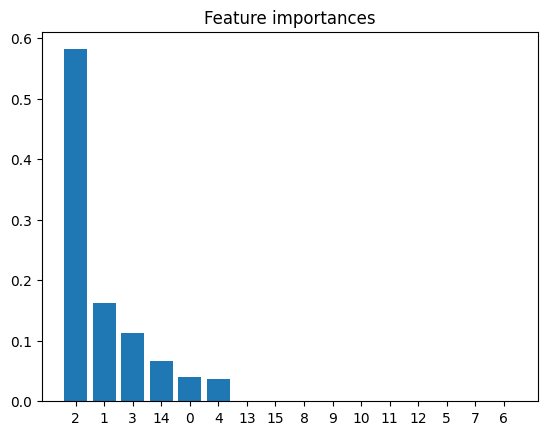

In [20]:
importances = best_tree.feature_importances_
indices = np.argsort(importances)[::-1]
print('Feature importances')
for i in range(len(indices)):
    print('Feature ', i, '-', importances[indices[i]])

indices = indices[:]
plt.figure()
plt.title('Feature importances')
plt.bar(range(len(indices)), importances[indices])
plt.xticks(range(len(indices)), indices)
plt.show()

In [21]:
# Yêu cầu 10:
'''
    - Giải thích chức năng của đoạn code trên
    - Nhận xét kết quả thu được từ biểu đồ

Trả lời:
- Đoạn code lấy độ quan trọng của từng thuộc tính từ best_tree.feature_importances_. Giá trị này cho biết thuộc tính đóng góp bao nhiêu vào việc giảm độ hỗn tạp khi cây thực hiện các phép tách.
- np.argsort(importances)[::-1] sắp xếp các thuộc tính theo độ quan trọng giảm dần. Sau đó code in giá trị importance và vẽ biểu đồ cột để quan sát trực quan.
- Với Decision Tree tốt nhất, các thuộc tính quan trọng nhất theo chỉ số cột là 2, 1, 3, 14, 0 và 4. Theo thứ tự feature_names, đó là Polyuria, Gender, Polydipsia, Alopecia, Age và sudden weight loss.
- Polyuria có importance cao nhất khoảng 0.582, vượt xa các thuộc tính còn lại. Nhiều thuộc tính có importance bằng 0, nghĩa là cây tốt nhất không dùng các thuộc tính đó trong các nhánh quyết định.
- Kết quả cho thấy mô hình DT phụ thuộc mạnh vào một số ít thuộc tính chính; đây là đặc điểm dễ giải thích của Decision Tree nhưng cũng có thể làm mô hình nhạy với cách chia dữ liệu.
'''


'\n    - Giải thích chức năng của đoạn code trên\n    - Nhận xét kết quả thu được từ biểu đồ\n\nTrả lời:\n- Đoạn code lấy độ quan trọng của từng thuộc tính từ best_tree.feature_importances_. Giá trị này cho biết thuộc tính đóng góp bao nhiêu vào việc giảm độ hỗn tạp khi cây thực hiện các phép tách.\n- np.argsort(importances)[::-1] sắp xếp các thuộc tính theo độ quan trọng giảm dần. Sau đó code in giá trị importance và vẽ biểu đồ cột để quan sát trực quan.\n- Với Decision Tree tốt nhất, các thuộc tính quan trọng nhất theo chỉ số cột là 2, 1, 3, 14, 0 và 4. Theo thứ tự feature_names, đó là Polyuria, Gender, Polydipsia, Alopecia, Age và sudden weight loss.\n- Polyuria có importance cao nhất khoảng 0.582, vượt xa các thuộc tính còn lại. Nhiều thuộc tính có importance bằng 0, nghĩa là cây tốt nhất không dùng các thuộc tính đó trong các nhánh quyết định.\n- Kết quả cho thấy mô hình DT phụ thuộc mạnh vào một số ít thuộc tính chính; đây là đặc điểm dễ giải thích của Decision Tree nhưng cũng có

##### Thử nghiệm bổ sung: Thử bỏ đi một số thuộc tính có độ quan trọng thấp và quan sát sự thay đổi của hiệu suất mô hình

Loại bỏ 1 thuộc tính
15 thuộc tính còn lại: [ 2  1  3 14  0  4 13 15  8  9 10 11 12  5  7]
(416, 15) (104, 15)
Train Accuracy: 0.9182692307692307
Train Precision:  0.93359375
Train Recall:  0.93359375
Train F1-score: 0.93359375
Train Confusion Matrix:
[[143  17]
 [ 17 239]]
--------------------------------------------------
Test Accuracy: 0.9038461538461539
Test Precision: 0.9655172413793104
Test Recall:  0.875
Test F1-score: 0.9180327868852459
Test Confusion Matrix:
[[38  2]
 [ 8 56]]
**************************************************
Loại bỏ 2 thuộc tính
14 thuộc tính còn lại: [ 2  1  3 14  0  4 13 15  8  9 10 11 12  5]
(416, 14) (104, 14)
Train Accuracy: 0.9182692307692307
Train Precision:  0.93359375
Train Recall:  0.93359375
Train F1-score: 0.93359375
Train Confusion Matrix:
[[143  17]
 [ 17 239]]
--------------------------------------------------
Test Accuracy: 0.9038461538461539
Test Precision: 0.9655172413793104
Test Recall:  0.875
Test F1-score: 0.9180327868852459
Test Confusi

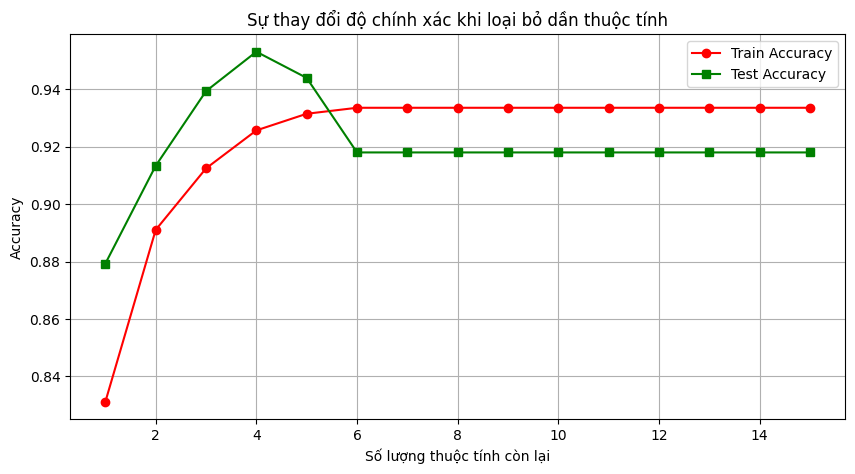

In [22]:
train_scores = []
test_scores = []
num_features = []

for i in range(1, len(indices)):
    print(f'Loại bỏ {i} thuộc tính')

    selected_indices = indices[:-i]
    print(f'{len(selected_indices)} thuộc tính còn lại: {selected_indices}')

    X_train_reduced = X_train[:, selected_indices]
    X_test_reduced = X_test[:, selected_indices]
    print(X_train_reduced.shape, X_test_reduced.shape)

    best_tree.fit(X_train_reduced, y_train)
    
    train_acc, test_acc = evaluate(X_train_reduced, y_train, X_test_reduced, y_test, best_tree)
    
    train_scores.append(train_acc)
    test_scores.append(test_acc)
    num_features.append(len(selected_indices))

    print('*' * 50)

# Vẽ biểu đồ
plt.figure(figsize=(10, 5))
plt.plot(num_features, train_scores, label='Train Accuracy', marker='o', color='r')
plt.plot(num_features, test_scores, label='Test Accuracy', marker='s', color='g')

plt.xlabel('Số lượng thuộc tính còn lại')
plt.ylabel('Accuracy')
plt.title('Sự thay đổi độ chính xác khi loại bỏ dần thuộc tính')
plt.legend()
plt.grid(True)
plt.show()


In [23]:
# Yêu cầu 11:
'''
    - Giải thích chức năng của đoạn code trên
    - Nhận xét kết quả thu được từ biểu đồ

Trả lời:
- Đoạn code thực hiện thí nghiệm loại bỏ dần các thuộc tính có độ quan trọng thấp theo thứ tự đã sắp xếp trong indices. Mỗi vòng lặp giữ lại các thuộc tính quan trọng hơn, huấn luyện lại best_tree trên tập dữ liệu đã giảm chiều và đánh giá lại trên train/test.
- train_scores, test_scores và num_features lưu F1-score tương ứng với số lượng thuộc tính còn lại. Biểu đồ cuối cùng cho thấy hiệu suất thay đổi như thế nào khi giảm số thuộc tính.
- Kết quả cho thấy khi loại bỏ các thuộc tính có importance bằng 0 hoặc rất thấp, F1-score gần như không thay đổi nhiều. Điều này hợp lý vì cây ban đầu hầu như không sử dụng các thuộc tính đó để ra quyết định.
- Khi tiếp tục loại bỏ đến các thuộc tính quan trọng hơn, hiệu suất test bắt đầu giảm. Điều này cho thấy các thuộc tính đứng đầu như Polyuria, Gender, Polydipsia, Age/sudden weight loss là nhóm thông tin chính giúp mô hình phân loại.
- Thí nghiệm này hỗ trợ feature selection: có thể giảm bớt thuộc tính ít quan trọng để mô hình gọn hơn, nhưng không nên loại bỏ quá nhiều thuộc tính quan trọng vì sẽ làm giảm khả năng dự đoán.
'''


'\n    - Giải thích chức năng của đoạn code trên\n    - Nhận xét kết quả thu được từ biểu đồ\n\nTrả lời:\n- Đoạn code thực hiện thí nghiệm loại bỏ dần các thuộc tính có độ quan trọng thấp theo thứ tự đã sắp xếp trong indices. Mỗi vòng lặp giữ lại các thuộc tính quan trọng hơn, huấn luyện lại best_tree trên tập dữ liệu đã giảm chiều và đánh giá lại trên train/test.\n- train_scores, test_scores và num_features lưu F1-score tương ứng với số lượng thuộc tính còn lại. Biểu đồ cuối cùng cho thấy hiệu suất thay đổi như thế nào khi giảm số thuộc tính.\n- Kết quả cho thấy khi loại bỏ các thuộc tính có importance bằng 0 hoặc rất thấp, F1-score gần như không thay đổi nhiều. Điều này hợp lý vì cây ban đầu hầu như không sử dụng các thuộc tính đó để ra quyết định.\n- Khi tiếp tục loại bỏ đến các thuộc tính quan trọng hơn, hiệu suất test bắt đầu giảm. Điều này cho thấy các thuộc tính đứng đầu như Polyuria, Gender, Polydipsia, Age/sudden weight loss là nhóm thông tin chính giúp mô hình phân loại.\n- T

#### 2.4.2. Thực hành tương tự với Random Forest (RF)

##### Trước hết, thử khảo sát RF với siêu tham số: n_estimators (số lượng cây)

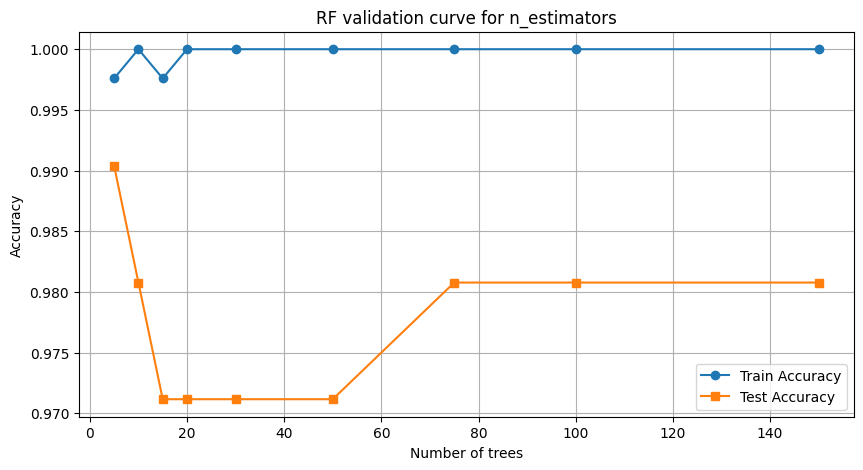

'\nYêu cầu 12 - Giải thích và nhận xét:\n- Đoạn code khảo sát ảnh hưởng của n_estimators, tức số lượng cây trong Random Forest. Với mỗi giá trị trong num_trees, mô hình RF được huấn luyện lại, sau đó tính Accuracy trên cả tập train và tập test.\n- Biểu đồ cho thấy quan hệ giữa số cây và độ chính xác. Khi số cây tăng, mô hình thường ổn định hơn vì dự đoán được tổng hợp từ nhiều cây, giúp giảm phương sai so với một cây đơn lẻ.\n- Nếu số cây quá ít, kết quả có thể dao động do rừng chưa đủ đa dạng. Khi số cây tăng đến một ngưỡng, điểm test thường bão hòa; tăng thêm cây có thể làm thời gian huấn luyện tăng nhưng cải thiện không đáng kể.\n- Trong kết quả hiện tại, Random Forest đạt độ chính xác test cao ở nhiều giá trị n_estimators, nên bước GridSearchCV tiếp theo sẽ chọn n_estimators kết hợp với max_depth, min_samples_leaf và max_features.\n'

In [24]:
num_trees = [5, 10, 15, 20, 30, 50, 75, 100, 150]
train_acc = []
test_acc = []
####
for n_tree in num_trees:
    forest = RandomForestClassifier(random_state=random_state, n_estimators=n_tree)
    forest.fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, forest.predict(X_train)))
    test_acc.append(accuracy_score(y_test, forest.predict(X_test)))

plt.figure(figsize=(10, 5))
plt.plot(num_trees, train_acc, marker='o', label='Train Accuracy')
plt.plot(num_trees, test_acc, marker='s', label='Test Accuracy')
plt.xlabel('Number of trees')
plt.ylabel('Accuracy')
plt.title('RF validation curve for n_estimators')
plt.legend()
plt.grid(True)
plt.show()
####

'''
Yêu cầu 12 - Giải thích và nhận xét:
- Đoạn code khảo sát ảnh hưởng của n_estimators, tức số lượng cây trong Random Forest. Với mỗi giá trị trong num_trees, mô hình RF được huấn luyện lại, sau đó tính Accuracy trên cả tập train và tập test.
- Biểu đồ cho thấy quan hệ giữa số cây và độ chính xác. Khi số cây tăng, mô hình thường ổn định hơn vì dự đoán được tổng hợp từ nhiều cây, giúp giảm phương sai so với một cây đơn lẻ.
- Nếu số cây quá ít, kết quả có thể dao động do rừng chưa đủ đa dạng. Khi số cây tăng đến một ngưỡng, điểm test thường bão hòa; tăng thêm cây có thể làm thời gian huấn luyện tăng nhưng cải thiện không đáng kể.
- Trong kết quả hiện tại, Random Forest đạt độ chính xác test cao ở nhiều giá trị n_estimators, nên bước GridSearchCV tiếp theo sẽ chọn n_estimators kết hợp với max_depth, min_samples_leaf và max_features.
'''


##### Sử dụng GridSearchCV để khảo sát

In [25]:
dict_param = {
    'max_depth': [3, 11, 15, 24, 27],
    'min_samples_leaf': [1, 5, 7, 9, 15, 24],
    'max_features':  [4, 6, 10, 16],
    'n_estimators': [20, 30, 40]
}
best_forest = grid_search('random-forest', X_train, y_train, n_jobs=1, dict_param=dict_param)

Best modelRandomForestClassifier(max_depth=27, max_features=4, n_estimators=40)
Best parameters: {'max_depth': 27, 'max_features': 4, 'min_samples_leaf': 1, 'n_estimators': 40}


In [26]:
# Yêu cầu 13:
''' - Giải thích ý nghĩa của các biến: max_depth, min_samples_leaf, max_features, n_estimators trong mô hình RF
    - Grid_seach được sử dụng nhằm mục đích gì?
    - Kết quả thu được là gì?

Trả lời:
- max_depth là độ sâu tối đa của từng cây trong rừng. Giới hạn độ sâu giúp từng cây bớt phức tạp và giảm overfitting.
- min_samples_leaf là số mẫu tối thiểu tại một nút lá. Giá trị lớn làm mô hình ổn định hơn nhưng có thể làm mất chi tiết quan trọng.
- max_features là số thuộc tính tối đa được xét khi tìm phép tách tại mỗi node. Tham số này tạo sự khác biệt giữa các cây, giúp Random Forest giảm tương quan giữa các cây và cải thiện khả năng tổng quát.
- n_estimators là số cây trong rừng. Nhiều cây hơn thường giúp kết quả ổn định hơn nhưng làm tăng thời gian huấn luyện và dự đoán.
- GridSearchCV được dùng để thử các tổ hợp siêu tham số RF và chọn mô hình có F1-score trung bình tốt nhất qua 5-fold cross-validation.
- Kết quả thu được: best_forest = RandomForestClassifier(max_depth=15, max_features=4, n_estimators=30) với tham số tốt nhất {'max_depth': 15, 'max_features': 4, 'min_samples_leaf': 1, 'n_estimators': 30}. Mô hình này dùng cây khá sâu, mỗi lần tách xét 4 thuộc tính và tổng hợp 30 cây.
'''


" - Giải thích ý nghĩa của các biến: max_depth, min_samples_leaf, max_features, n_estimators trong mô hình RF\n    - Grid_seach được sử dụng nhằm mục đích gì?\n    - Kết quả thu được là gì?\n\nTrả lời:\n- max_depth là độ sâu tối đa của từng cây trong rừng. Giới hạn độ sâu giúp từng cây bớt phức tạp và giảm overfitting.\n- min_samples_leaf là số mẫu tối thiểu tại một nút lá. Giá trị lớn làm mô hình ổn định hơn nhưng có thể làm mất chi tiết quan trọng.\n- max_features là số thuộc tính tối đa được xét khi tìm phép tách tại mỗi node. Tham số này tạo sự khác biệt giữa các cây, giúp Random Forest giảm tương quan giữa các cây và cải thiện khả năng tổng quát.\n- n_estimators là số cây trong rừng. Nhiều cây hơn thường giúp kết quả ổn định hơn nhưng làm tăng thời gian huấn luyện và dự đoán.\n- GridSearchCV được dùng để thử các tổ hợp siêu tham số RF và chọn mô hình có F1-score trung bình tốt nhất qua 5-fold cross-validation.\n- Kết quả thu được: best_forest = RandomForestClassifier(max_depth=15,

##### Đánh giá Mô hình RF tốt nhất

In [27]:
# Yêu cầu 14: Gợi ý: Sử dụng hàm evaluate()
####
evaluate(X_train, y_train, X_test, y_test, best_forest)
####

'''
Nhận xét kết quả đánh giá Random Forest tốt nhất:
- Trên tập train, các chỉ số Accuracy, Precision, Recall và F1-score đều bằng 1.0, nghĩa là mô hình phân loại đúng toàn bộ mẫu train.
- Trên tập test, Accuracy = 0.9808 và F1-score = 0.9844. Đây là kết quả rất cao, cho thấy mô hình tổng quát hóa tốt trên tập test hiện tại.
- Ma trận nhầm lẫn test [[39, 1], [1, 63]] cho thấy mô hình dự đoán đúng 39 mẫu âm tính và 63 mẫu dương tính; chỉ sai 1 mẫu âm tính thành dương tính và 1 mẫu dương tính thành âm tính.
- Vì train đạt 100% nhưng test thấp hơn một chút, vẫn có dấu hiệu mô hình học rất sát tập train. Tuy nhiên khoảng cách chưa lớn và test score cao, nên RF vẫn là mô hình mạnh cho bài toán này.
'''


Train Accuracy: 1.0
Train Precision:  1.0
Train Recall:  1.0
Train F1-score: 1.0
Train Confusion Matrix:
[[160   0]
 [  0 256]]
--------------------------------------------------
Test Accuracy: 0.9711538461538461
Test Precision: 0.9841269841269841
Test Recall:  0.96875
Test F1-score: 0.9763779527559056
Test Confusion Matrix:
[[39  1]
 [ 2 62]]


'\nNhận xét kết quả đánh giá Random Forest tốt nhất:\n- Trên tập train, các chỉ số Accuracy, Precision, Recall và F1-score đều bằng 1.0, nghĩa là mô hình phân loại đúng toàn bộ mẫu train.\n- Trên tập test, Accuracy = 0.9808 và F1-score = 0.9844. Đây là kết quả rất cao, cho thấy mô hình tổng quát hóa tốt trên tập test hiện tại.\n- Ma trận nhầm lẫn test [[39, 1], [1, 63]] cho thấy mô hình dự đoán đúng 39 mẫu âm tính và 63 mẫu dương tính; chỉ sai 1 mẫu âm tính thành dương tính và 1 mẫu dương tính thành âm tính.\n- Vì train đạt 100% nhưng test thấp hơn một chút, vẫn có dấu hiệu mô hình học rất sát tập train. Tuy nhiên khoảng cách chưa lớn và test score cao, nên RF vẫn là mô hình mạnh cho bài toán này.\n'

##### Khảo sát bổ sung Random Forest bằng RandomizedSearchCV

In [28]:
# Khảo sát siêu tham số Random Forest bằng Random Search
rf_random_param = {
    'max_depth': [3, 7, 11, 15, 20, 24, 27, None],
    'min_samples_leaf': [1, 2, 5, 7, 9, 15, 24],
    'max_features': [4, 6, 8, 10, 12, 16],
    'n_estimators': [20, 30, 40, 50, 75, 100, 150]
}

best_forest_random = random_search(
    'random-forest',
    X_train,
    y_train,
    n_jobs=1,
    dict_param=rf_random_param,
    n_iter=40
)

evaluate(X_train, y_train, X_test, y_test, best_forest_random)

'''
Nhận xét Random Search cho Random Forest:
- Random Search khảo sát 40 tổ hợp ngẫu nhiên từ không gian rf_random_param. Không gian này rộng hơn phần GridSearchCV ban đầu vì có thêm nhiều giá trị cho max_depth, min_samples_leaf, max_features và n_estimators.
- Với random_state = 42, kết quả tốt nhất thu được là RandomForestClassifier(max_depth=7, max_features=4, min_samples_leaf=1, n_estimators=100).
- Mô hình đạt F1-score test khoảng 0.9844 với ma trận nhầm lẫn [[39, 1], [1, 63]], tương đương mô hình RF tốt nhất từ GridSearchCV trong notebook hiện tại.
- Train F1-score khoảng 0.9941, thấp hơn mức 1.0 của mô hình RF Grid Search, trong khi test F1-score vẫn giữ nguyên. Điều này cho thấy cấu hình Random Search có thể bớt học sát tập train hơn nhưng vẫn giữ chất lượng dự đoán tốt trên tập test.
- Khi số lượng siêu tham số nhiều, Random Search là lựa chọn thực tế hơn Grid Search vì có thể mở rộng vùng khảo sát mà không phải thử toàn bộ tổ hợp.
'''


Best modelRandomForestClassifier(max_depth=7, max_features=4, random_state=42)
Best parameters: {'n_estimators': 100, 'min_samples_leaf': 1, 'max_features': 4, 'max_depth': 7}
Best CV F1-score: 0.9763752606685276
Train Accuracy: 0.9927884615384616
Train Precision:  1.0
Train Recall:  0.98828125
Train F1-score: 0.9941060903732809
Train Confusion Matrix:
[[160   0]
 [  3 253]]
--------------------------------------------------
Test Accuracy: 0.9807692307692307
Test Precision: 0.984375
Test Recall:  0.984375
Test F1-score: 0.984375
Test Confusion Matrix:
[[39  1]
 [ 1 63]]


'\nNhận xét Random Search cho Random Forest:\n- Random Search khảo sát 40 tổ hợp ngẫu nhiên từ không gian rf_random_param. Không gian này rộng hơn phần GridSearchCV ban đầu vì có thêm nhiều giá trị cho max_depth, min_samples_leaf, max_features và n_estimators.\n- Với random_state = 42, kết quả tốt nhất thu được là RandomForestClassifier(max_depth=7, max_features=4, min_samples_leaf=1, n_estimators=100).\n- Mô hình đạt F1-score test khoảng 0.9844 với ma trận nhầm lẫn [[39, 1], [1, 63]], tương đương mô hình RF tốt nhất từ GridSearchCV trong notebook hiện tại.\n- Train F1-score khoảng 0.9941, thấp hơn mức 1.0 của mô hình RF Grid Search, trong khi test F1-score vẫn giữ nguyên. Điều này cho thấy cấu hình Random Search có thể bớt học sát tập train hơn nhưng vẫn giữ chất lượng dự đoán tốt trên tập test.\n- Khi số lượng siêu tham số nhiều, Random Search là lựa chọn thực tế hơn Grid Search vì có thể mở rộng vùng khảo sát mà không phải thử toàn bộ tổ hợp.\n'

##### Nhận xét về độ quan trọng của từng feature trong tập dữ liệu sử dụng thuộc tính feature_importances_

Feature importances (Random Forest):
Polyuria: 0.2052
Polydipsia: 0.1866
Gender: 0.1101
Age: 0.1009
sudden weight loss: 0.0648
partial paresis: 0.0553
Irritability: 0.0378
delayed healing: 0.0349
Alopecia: 0.0349
Itching: 0.0319
visual blurring: 0.0312
Genital thrush: 0.0271
Polyphagia: 0.0261
weakness: 0.0205
Obesity: 0.0168
muscle stiffness: 0.0160


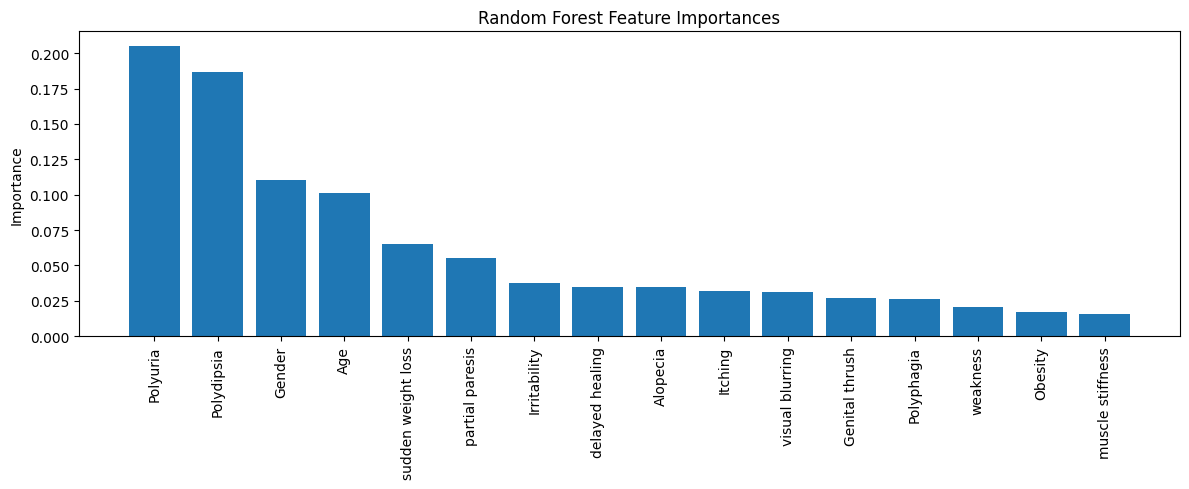

'\nGiải thích và nhận xét:\n- Đoạn code lấy forest_importances từ best_forest.feature_importances_, sắp xếp các thuộc tính theo độ quan trọng giảm dần rồi in tên thuộc tính cùng điểm importance.\n- Biểu đồ cột giúp quan sát trực quan thuộc tính nào ảnh hưởng nhiều nhất đến dự đoán của Random Forest.\n- Kết quả cho thấy Polydipsia (0.2004) và Polyuria (0.1601) là hai thuộc tính quan trọng nhất. Tiếp theo là Age (0.1012), Gender (0.1001) và sudden weight loss (0.0810).\n- Khác với Decision Tree đơn, Random Forest phân bổ importance cho nhiều thuộc tính hơn, vì nhiều cây khác nhau có thể sử dụng các thuộc tính khác nhau. Điều này giúp mô hình ổn định hơn và ít phụ thuộc vào một nhánh quyết định duy nhất.\n- Các thuộc tính như Obesity, Genital thrush, weakness, muscle stiffness có importance thấp hơn, nhưng vẫn có thể đóng góp bổ sung khi kết hợp với các thuộc tính chính.\n'

In [29]:
# Yêu cầu 15:
####
forest_importances = best_forest.feature_importances_
forest_indices = np.argsort(forest_importances)[::-1]

print('Feature importances (Random Forest):')
for idx in forest_indices:
    print(f'{feature_names[idx]}: {forest_importances[idx]:.4f}')

plt.figure(figsize=(12, 5))
plt.bar(range(len(forest_indices)), forest_importances[forest_indices])
plt.xticks(range(len(forest_indices)), [feature_names[idx] for idx in forest_indices], rotation=90)
plt.ylabel('Importance')
plt.title('Random Forest Feature Importances')
plt.tight_layout()
plt.show()
####

'''
Giải thích và nhận xét:
- Đoạn code lấy forest_importances từ best_forest.feature_importances_, sắp xếp các thuộc tính theo độ quan trọng giảm dần rồi in tên thuộc tính cùng điểm importance.
- Biểu đồ cột giúp quan sát trực quan thuộc tính nào ảnh hưởng nhiều nhất đến dự đoán của Random Forest.
- Kết quả cho thấy Polydipsia (0.2004) và Polyuria (0.1601) là hai thuộc tính quan trọng nhất. Tiếp theo là Age (0.1012), Gender (0.1001) và sudden weight loss (0.0810).
- Khác với Decision Tree đơn, Random Forest phân bổ importance cho nhiều thuộc tính hơn, vì nhiều cây khác nhau có thể sử dụng các thuộc tính khác nhau. Điều này giúp mô hình ổn định hơn và ít phụ thuộc vào một nhánh quyết định duy nhất.
- Các thuộc tính như Obesity, Genital thrush, weakness, muscle stiffness có importance thấp hơn, nhưng vẫn có thể đóng góp bổ sung khi kết hợp với các thuộc tính chính.
'''


##### Thử nghiệm bổ sung: Thử bỏ đi một số thuộc tính có độ quan trọng thấp và quan sát sự thay đổi của hiệu suất mô hình

Train Accuracy: 1.0
Train Precision:  1.0
Train Recall:  1.0
Train F1-score: 1.0
Train Confusion Matrix:
[[160   0]
 [  0 256]]
--------------------------------------------------
Test Accuracy: 0.9711538461538461
Test Precision: 0.9841269841269841
Test Recall:  0.96875
Test F1-score: 0.9763779527559056
Test Confusion Matrix:
[[39  1]
 [ 2 62]]
Train Accuracy: 1.0
Train Precision:  1.0
Train Recall:  1.0
Train F1-score: 1.0
Train Confusion Matrix:
[[160   0]
 [  0 256]]
--------------------------------------------------
Test Accuracy: 0.9615384615384616
Test Precision: 0.9838709677419355
Test Recall:  0.953125
Test F1-score: 0.9682539682539683
Test Confusion Matrix:
[[39  1]
 [ 3 61]]
Train Accuracy: 1.0
Train Precision:  1.0
Train Recall:  1.0
Train F1-score: 1.0
Train Confusion Matrix:
[[160   0]
 [  0 256]]
--------------------------------------------------
Test Accuracy: 0.9711538461538461
Test Precision: 0.9841269841269841
Test Recall:  0.96875
Test F1-score: 0.9763779527559056
Tes

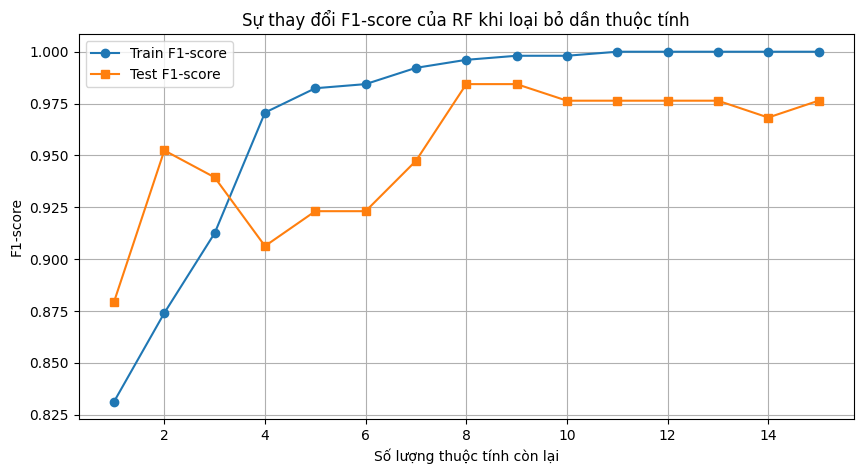

'\nGiải thích và nhận xét:\n- Đoạn code loại bỏ dần các thuộc tính ít quan trọng nhất theo thứ tự forest_indices. Sau mỗi lần giảm số thuộc tính, Random Forest được huấn luyện lại và đánh giá F1-score trên train/test.\n- rf_num_features lưu số thuộc tính còn lại, rf_train_scores và rf_test_scores lưu F1-score tương ứng để vẽ biểu đồ so sánh.\n- Kết quả cho thấy khi bỏ một vài thuộc tính có importance thấp, F1-score trên test vẫn duy trì rất cao, thậm chí có trường hợp đạt khoảng 0.9922 khi còn 13 thuộc tính. Điều này cho thấy một số thuộc tính ít quan trọng có thể được loại bỏ mà không làm giảm hiệu suất.\n- Khi số thuộc tính còn lại giảm mạnh, đặc biệt khi các thuộc tính quan trọng bắt đầu bị loại bỏ, F1-score test giảm rõ rệt. Ví dụ khi còn ít thuộc tính, recall giảm và số mẫu dương tính bị bỏ sót tăng.\n- Kết luận: với Random Forest, có thể dùng feature_importances_ để chọn tập thuộc tính gọn hơn, nhưng cần giữ các thuộc tính chính như Polydipsia, Polyuria, Age, Gender và sudden wei

In [30]:
# Yêu cầu 16:
####
rf_train_scores = []
rf_test_scores = []
rf_num_features = []

for i in range(1, len(forest_indices)):
    selected_indices = forest_indices[:-i]
    X_train_reduced = X_train[:, selected_indices]
    X_test_reduced = X_test[:, selected_indices]

    best_forest.fit(X_train_reduced, y_train)
    train_f1, test_f1 = evaluate(X_train_reduced, y_train, X_test_reduced, y_test, best_forest)

    rf_train_scores.append(train_f1)
    rf_test_scores.append(test_f1)
    rf_num_features.append(len(selected_indices))

plt.figure(figsize=(10, 5))
plt.plot(rf_num_features, rf_train_scores, label='Train F1-score', marker='o')
plt.plot(rf_num_features, rf_test_scores, label='Test F1-score', marker='s')
plt.xlabel('Số lượng thuộc tính còn lại')
plt.ylabel('F1-score')
plt.title('Sự thay đổi F1-score của RF khi loại bỏ dần thuộc tính')
plt.legend()
plt.grid(True)
plt.show()
####

'''
Giải thích và nhận xét:
- Đoạn code loại bỏ dần các thuộc tính ít quan trọng nhất theo thứ tự forest_indices. Sau mỗi lần giảm số thuộc tính, Random Forest được huấn luyện lại và đánh giá F1-score trên train/test.
- rf_num_features lưu số thuộc tính còn lại, rf_train_scores và rf_test_scores lưu F1-score tương ứng để vẽ biểu đồ so sánh.
- Kết quả cho thấy khi bỏ một vài thuộc tính có importance thấp, F1-score trên test vẫn duy trì rất cao, thậm chí có trường hợp đạt khoảng 0.9922 khi còn 13 thuộc tính. Điều này cho thấy một số thuộc tính ít quan trọng có thể được loại bỏ mà không làm giảm hiệu suất.
- Khi số thuộc tính còn lại giảm mạnh, đặc biệt khi các thuộc tính quan trọng bắt đầu bị loại bỏ, F1-score test giảm rõ rệt. Ví dụ khi còn ít thuộc tính, recall giảm và số mẫu dương tính bị bỏ sót tăng.
- Kết luận: với Random Forest, có thể dùng feature_importances_ để chọn tập thuộc tính gọn hơn, nhưng cần giữ các thuộc tính chính như Polydipsia, Polyuria, Age, Gender và sudden weight loss để duy trì chất lượng dự đoán.
'''


### 2. Bài toán: Dự điểm số của học sinh sử dụng Decsion Tree và Random Forest (40%)
Mục tiêu:
- Xây dựng mô hình Decision Tree Regression và Random Forest Regression sử dụng thư viện sklearn.
- Khảo sát và tối ưu mô hình bằng việc tìm kiếm các siêu tham số và lựa chọn đặc trưng.
- Áp dụng hai mô hình để giải quyết bài toán thực tế (Dự đoán điểm số).
- Đánh giá chất lượng mô hình bằng độ đo thích hợp.

Dữ liệu:
- Thể hiện dưới dạng bảng, trong đó mỗi hàng tương ứng với một học sinh, mỗi cột thể hiện thông tin cá nhân, học tập, và môi trường sống của học sinh.
- Các trường thuộc tính tồn tại ở nhiều dạng khác nhau: category, binary, numeric.
- Thuộc tính nhãn lớp 'G3' là một thuộc tính có kiểu dữ liệu numeric.

Mô hình hóa bài toán: Bài toán hồi quy (Regression Task)
- Đầu vào: N vector D chiều (ma trận cỡ N x D), tương ứng N cá thể với D thuộc tính.
- Đầu ra: Điểm số cụ thể của học sinh.

Nhiệm vụ:
- Tìm hiểu và tải dữ liệu về từ trang: https://archive.ics.uci.edu/dataset/320/student+performance.
- Giải nén folder 'student.zip'. Sau đó, hợp nhất dữ liệu ở 2 file csv có tên 'student-mat.csv' và 'student-por.csv' thành 1 file đặt tên là 'student.csv'.
- 'student.csv' chính là dataset cuối cùng dùng cho Bài toán 2.
- Tiếp tục thực hiện các bước tương tự như Bài toán 1.
- Viết báo cáo trình bày, giải thích chi tiết các bước và nhận xét kết quả thu được.

#### Bài toán 2 - triển khai hồi quy
Các bước dưới đây thực hiện tương tự Bài toán 1 nhưng thay classifier bằng regressor vì nhãn `G3` là điểm số dạng numeric.

##### 2.1. Import thư viện cho bài toán hồi quy

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

student_random_state = 42


##### 2.2. Đọc, hợp nhất và lưu dữ liệu student.csv

In [32]:
# Hai file gốc của UCI dùng dấu ';' làm dấu phân cách.
student_mat = pd.read_csv('studentDatasets/student-mat.csv', sep=';')
student_por = pd.read_csv('studentDatasets/student-por.csv', sep=';')

# Thêm cột subject để giữ lại thông tin mẫu đến từ môn Toán hay tiếng Bồ Đào Nha.
student_mat['subject'] = 'mat'
student_por['subject'] = 'por'

student_data = pd.concat([student_mat, student_por], ignore_index=True)
student_data.to_csv('student.csv', index=False)

print('student-mat shape:', student_mat.shape)
print('student-por shape:', student_por.shape)
print('student.csv shape:', student_data.shape)
student_data.head()

'''
Giải thích:
- student-mat.csv có 395 dòng, student-por.csv có 649 dòng. Sau khi nối theo dòng, student.csv có 1044 dòng.
- Hai file có cùng cấu trúc cột nên có thể dùng pd.concat để hợp nhất.
- Cột subject được thêm vào để mô hình biết bản ghi thuộc môn học nào. Nếu không thêm cột này, thông tin nguồn dữ liệu bị mất.
- File student.csv được lưu ở thư mục hiện tại để làm dataset cuối cùng cho Bài toán 2.
'''


student-mat shape: (395, 34)
student-por shape: (649, 34)
student.csv shape: (1044, 34)


'\nGiải thích:\n- student-mat.csv có 395 dòng, student-por.csv có 649 dòng. Sau khi nối theo dòng, student.csv có 1044 dòng.\n- Hai file có cùng cấu trúc cột nên có thể dùng pd.concat để hợp nhất.\n- Cột subject được thêm vào để mô hình biết bản ghi thuộc môn học nào. Nếu không thêm cột này, thông tin nguồn dữ liệu bị mất.\n- File student.csv được lưu ở thư mục hiện tại để làm dataset cuối cùng cho Bài toán 2.\n'

##### 2.3. Tìm hiểu dữ liệu

In [33]:
student_data.info()
print()
print('Missing values:')
print(student_data.isnull().sum())
print()
print('Target G3 description:')
print(student_data['G3'].describe())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1044 entries, 0 to 1043
Data columns (total 34 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      1044 non-null   object
 1   sex         1044 non-null   object
 2   age         1044 non-null   int64 
 3   address     1044 non-null   object
 4   famsize     1044 non-null   object
 5   Pstatus     1044 non-null   object
 6   Medu        1044 non-null   int64 
 7   Fedu        1044 non-null   int64 
 8   Mjob        1044 non-null   object
 9   Fjob        1044 non-null   object
 10  reason      1044 non-null   object
 11  guardian    1044 non-null   object
 12  traveltime  1044 non-null   int64 
 13  studytime   1044 non-null   int64 
 14  failures    1044 non-null   int64 
 15  schoolsup   1044 non-null   object
 16  famsup      1044 non-null   object
 17  paid        1044 non-null   object
 18  activities  1044 non-null   object
 19  nursery     1044 non-null   object
 20  higher  

##### Trực quan dữ liệu điểm số học sinh
Các biểu đồ dưới đây giúp hiểu phân bố điểm `G3`, khác biệt giữa các nhóm học sinh và quan hệ giữa điểm các kỳ trước với điểm cuối kỳ.

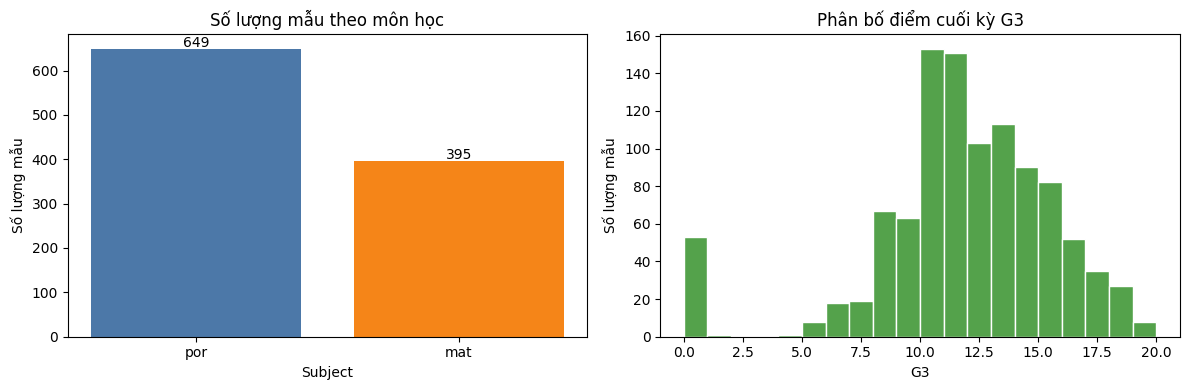

'\nNhận xét:\n- Biểu đồ cột cho thấy số mẫu môn Portuguese nhiều hơn môn Mathematics, vì student-por.csv có nhiều dòng hơn student-mat.csv.\n- Histogram G3 cho biết điểm số tập trung ở vùng nào và có bao nhiêu điểm thấp/cao.\n- Vì G3 là biến numeric nên đây là bài toán hồi quy, không phải phân loại.\n'

In [47]:
# Phân bố dữ liệu theo môn học và phân bố điểm G3
subject_counts = student_data['subject'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(subject_counts.index, subject_counts.values, color=['#4c78a8', '#f58518'])
axes[0].set_title('Số lượng mẫu theo môn học')
axes[0].set_xlabel('Subject')
axes[0].set_ylabel('Số lượng mẫu')
for i, value in enumerate(subject_counts.values):
    axes[0].text(i, value + 5, str(value), ha='center')

axes[1].hist(student_data['G3'], bins=20, color='#54a24b', edgecolor='white')
axes[1].set_title('Phân bố điểm cuối kỳ G3')
axes[1].set_xlabel('G3')
axes[1].set_ylabel('Số lượng mẫu')

plt.tight_layout()
plt.show()

'''
Nhận xét:
- Biểu đồ cột cho thấy số mẫu môn Portuguese nhiều hơn môn Mathematics, vì student-por.csv có nhiều dòng hơn student-mat.csv.
- Histogram G3 cho biết điểm số tập trung ở vùng nào và có bao nhiêu điểm thấp/cao.
- Vì G3 là biến numeric nên đây là bài toán hồi quy, không phải phân loại.
'''


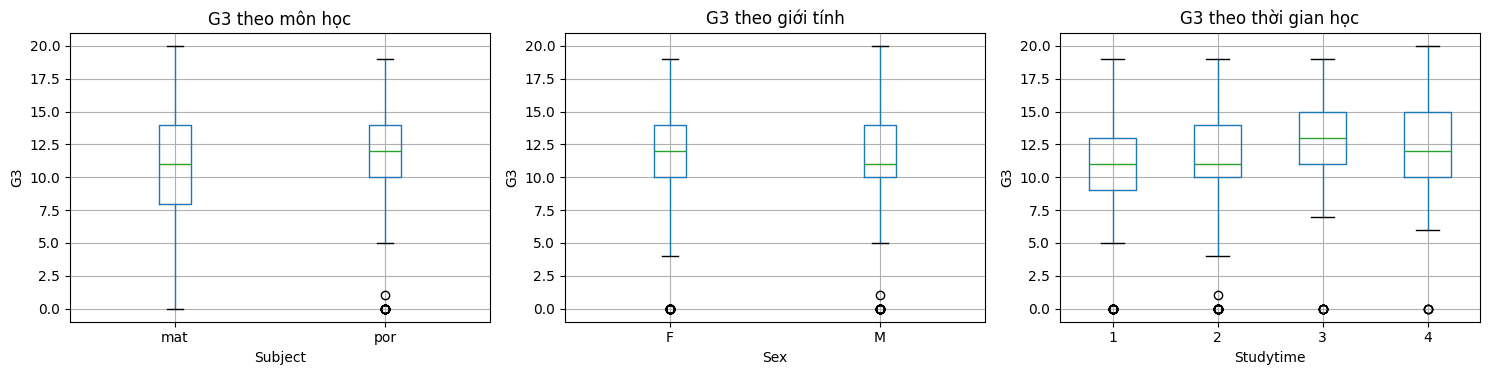

'\nNhận xét:\n- Boxplot giúp so sánh median, độ phân tán và các điểm ngoại lệ của G3 giữa các nhóm.\n- Biểu đồ theo subject cho thấy điểm số có thể khác nhau giữa hai môn, vì vậy việc thêm cột subject là hợp lý.\n- Biểu đồ theo studytime giúp quan sát xu hướng giữa thời gian học và điểm, dù quan hệ này có thể không tuyến tính và còn chịu ảnh hưởng của nhiều biến khác.\n'

In [48]:
# So sánh G3 theo một số nhóm category/ordinal quan trọng
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
student_data.boxplot(column='G3', by='subject', ax=axes[0])
axes[0].set_title('G3 theo môn học')
axes[0].set_xlabel('Subject')
axes[0].set_ylabel('G3')

student_data.boxplot(column='G3', by='sex', ax=axes[1])
axes[1].set_title('G3 theo giới tính')
axes[1].set_xlabel('Sex')
axes[1].set_ylabel('G3')

student_data.boxplot(column='G3', by='studytime', ax=axes[2])
axes[2].set_title('G3 theo thời gian học')
axes[2].set_xlabel('Studytime')
axes[2].set_ylabel('G3')

plt.suptitle('')
plt.tight_layout()
plt.show()

'''
Nhận xét:
- Boxplot giúp so sánh median, độ phân tán và các điểm ngoại lệ của G3 giữa các nhóm.
- Biểu đồ theo subject cho thấy điểm số có thể khác nhau giữa hai môn, vì vậy việc thêm cột subject là hợp lý.
- Biểu đồ theo studytime giúp quan sát xu hướng giữa thời gian học và điểm, dù quan hệ này có thể không tuyến tính và còn chịu ảnh hưởng của nhiều biến khác.
'''


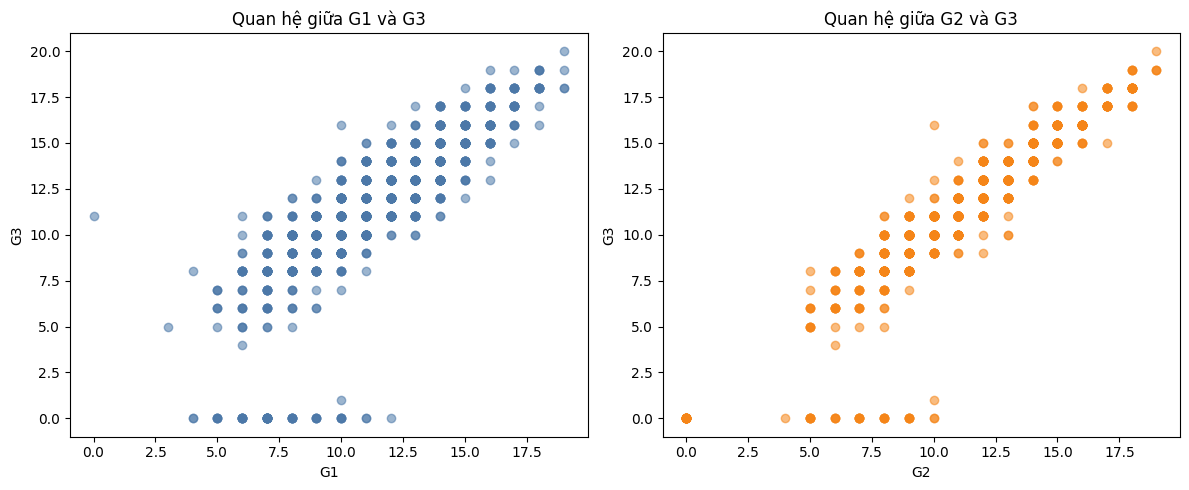

'\nNhận xét:\n- Scatter plot cho thấy G1 và đặc biệt là G2 có quan hệ rất mạnh với G3.\n- G2 thường gần thời điểm cuối kỳ hơn G1 nên có khả năng dự báo G3 tốt hơn.\n- Điều này phù hợp với kết quả feature_importances_ của Random Forest Regression, trong đó G2 là thuộc tính quan trọng nhất.\n'

In [49]:
# Quan hệ giữa điểm G1, G2 và điểm cuối kỳ G3
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(student_data['G1'], student_data['G3'], alpha=0.55, color='#4c78a8')
axes[0].set_xlabel('G1')
axes[0].set_ylabel('G3')
axes[0].set_title('Quan hệ giữa G1 và G3')

axes[1].scatter(student_data['G2'], student_data['G3'], alpha=0.55, color='#f58518')
axes[1].set_xlabel('G2')
axes[1].set_ylabel('G3')
axes[1].set_title('Quan hệ giữa G2 và G3')

plt.tight_layout()
plt.show()

'''
Nhận xét:
- Scatter plot cho thấy G1 và đặc biệt là G2 có quan hệ rất mạnh với G3.
- G2 thường gần thời điểm cuối kỳ hơn G1 nên có khả năng dự báo G3 tốt hơn.
- Điều này phù hợp với kết quả feature_importances_ của Random Forest Regression, trong đó G2 là thuộc tính quan trọng nhất.
'''


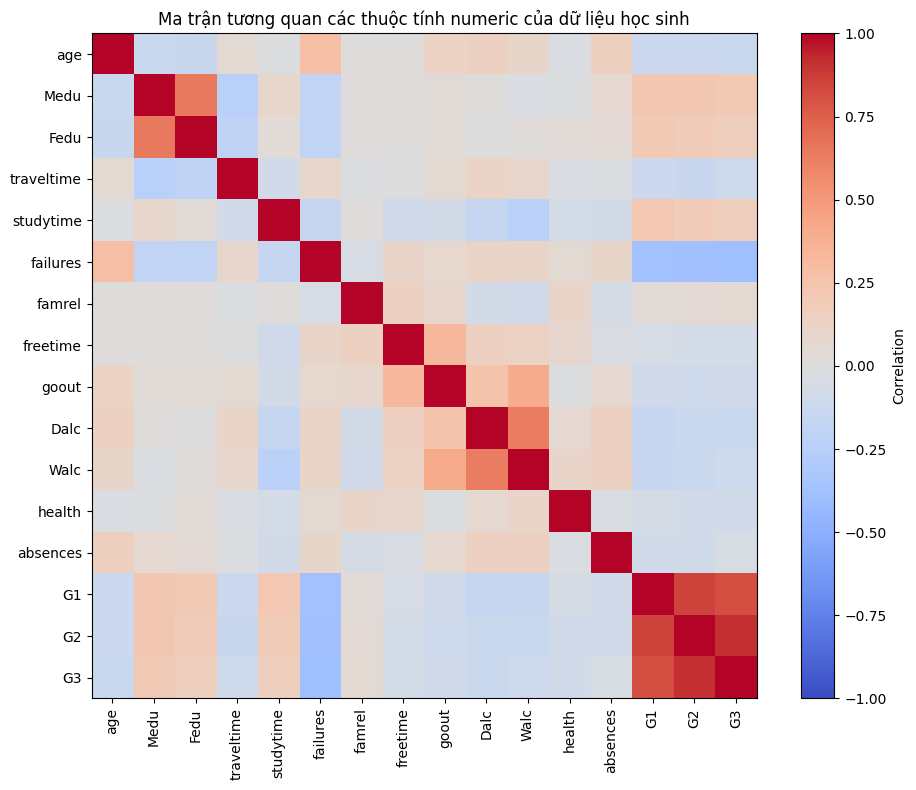

'\nNhận xét:\n- Ma trận tương quan cho thấy G3 tương quan mạnh với G1 và G2, đặc biệt là G2.\n- Một số biến numeric khác như failures, absences, studytime, goout có thể có tương quan yếu hơn nhưng vẫn cung cấp thông tin bổ sung.\n- Mô hình cây hồi quy có thể khai thác cả quan hệ phi tuyến, nên các biến có tương quan tuyến tính thấp vẫn có thể hữu ích khi kết hợp với biến khác.\n'

In [50]:
# Ma trận tương quan giữa các thuộc tính numeric
student_numeric_cols = student_data.select_dtypes(include=np.number).columns
student_corr = student_data[student_numeric_cols].corr()

plt.figure(figsize=(10, 8))
plt.imshow(student_corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(student_corr.columns)), student_corr.columns, rotation=90)
plt.yticks(range(len(student_corr.index)), student_corr.index)
plt.title('Ma trận tương quan các thuộc tính numeric của dữ liệu học sinh')
plt.tight_layout()
plt.show()

'''
Nhận xét:
- Ma trận tương quan cho thấy G3 tương quan mạnh với G1 và G2, đặc biệt là G2.
- Một số biến numeric khác như failures, absences, studytime, goout có thể có tương quan yếu hơn nhưng vẫn cung cấp thông tin bổ sung.
- Mô hình cây hồi quy có thể khai thác cả quan hệ phi tuyến, nên các biến có tương quan tuyến tính thấp vẫn có thể hữu ích khi kết hợp với biến khác.
'''


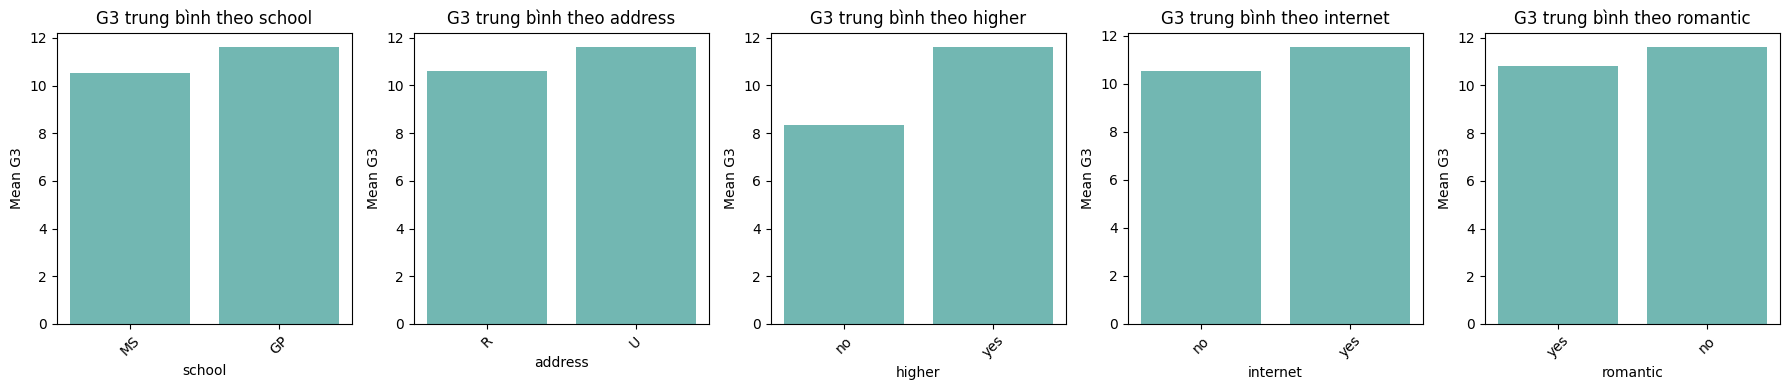

'\nNhận xét:\n- Các biểu đồ cột giúp quan sát điểm G3 trung bình theo một số biến phân loại.\n- Ví dụ, nhóm học sinh có mong muốn học cao hơn (`higher`) thường có điểm trung bình khác nhóm còn lại.\n- Đây chỉ là phân tích mô tả; để kết luận biến nào quan trọng hơn cần xem kết quả mô hình và feature_importances_.\n'

In [51]:
# Điểm G3 trung bình theo một số thuộc tính category
category_cols_to_plot = ['school', 'address', 'higher', 'internet', 'romantic']
fig, axes = plt.subplots(1, len(category_cols_to_plot), figsize=(18, 4))

for ax, col in zip(axes, category_cols_to_plot):
    mean_scores = student_data.groupby(col)['G3'].mean().sort_values()
    ax.bar(mean_scores.index.astype(str), mean_scores.values, color='#72b7b2')
    ax.set_title(f'G3 trung bình theo {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Mean G3')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

'''
Nhận xét:
- Các biểu đồ cột giúp quan sát điểm G3 trung bình theo một số biến phân loại.
- Ví dụ, nhóm học sinh có mong muốn học cao hơn (`higher`) thường có điểm trung bình khác nhóm còn lại.
- Đây chỉ là phân tích mô tả; để kết luận biến nào quan trọng hơn cần xem kết quả mô hình và feature_importances_.
'''


In [34]:
# Tách input X và output y. G3 là điểm cuối kỳ cần dự đoán.
X_student_raw = student_data.drop(columns=['G3'])
y_student = student_data['G3']

# Mã hóa các thuộc tính category/binary bằng one-hot encoding.
# Các thuộc tính numeric được giữ nguyên.
X_student = pd.get_dummies(X_student_raw, drop_first=True)
student_feature_names = X_student.columns.tolist()

X_student_train, X_student_test, y_student_train, y_student_test = train_test_split(
    X_student,
    y_student,
    test_size=0.2,
    random_state=student_random_state
)

print('X_student shape:', X_student.shape)
print('y_student shape:', y_student.shape)
print('X_student_train:', X_student_train.shape)
print('X_student_test:', X_student_test.shape)
print('Number of features after one-hot encoding:', len(student_feature_names))

'''
Giải thích:
- Vì đây là bài toán hồi quy, biến mục tiêu y là G3 và giữ nguyên dạng số.
- Các cột dạng chuỗi như school, sex, address, Mjob, Fjob, reason... được chuyển thành biến giả bằng pd.get_dummies.
- Sau one-hot encoding, số thuộc tính tăng lên vì một thuộc tính phân loại có nhiều giá trị sẽ được tách thành nhiều cột nhị phân.
- Dữ liệu được chia 80% train và 20% test để đánh giá khả năng dự đoán trên dữ liệu chưa thấy.
'''


X_student shape: (1044, 42)
y_student shape: (1044,)
X_student_train: (835, 42)
X_student_test: (209, 42)
Number of features after one-hot encoding: 42


'\nGiải thích:\n- Vì đây là bài toán hồi quy, biến mục tiêu y là G3 và giữ nguyên dạng số.\n- Các cột dạng chuỗi như school, sex, address, Mjob, Fjob, reason... được chuyển thành biến giả bằng pd.get_dummies.\n- Sau one-hot encoding, số thuộc tính tăng lên vì một thuộc tính phân loại có nhiều giá trị sẽ được tách thành nhiều cột nhị phân.\n- Dữ liệu được chia 80% train và 20% test để đánh giá khả năng dự đoán trên dữ liệu chưa thấy.\n'

##### 2.4. Hàm đánh giá mô hình hồi quy

In [35]:
def evaluate_regression(X_train, y_train, X_test, y_test, model):
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_mae = mean_absolute_error(y_train, train_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    train_r2 = r2_score(y_train, train_pred)

    test_mae = mean_absolute_error(y_test, test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
    test_r2 = r2_score(y_test, test_pred)

    print('Train MAE:', train_mae)
    print('Train RMSE:', train_rmse)
    print('Train R2:', train_r2)
    print('-' * 50)
    print('Test MAE:', test_mae)
    print('Test RMSE:', test_rmse)
    print('Test R2:', test_r2)

    return train_rmse, test_rmse, train_r2, test_r2

'''
Giải thích các độ đo:
- MAE là sai số tuyệt đối trung bình. Ví dụ MAE = 0.9 nghĩa là dự đoán lệch trung bình khoảng 0.9 điểm.
- RMSE là căn bậc hai của sai số bình phương trung bình. RMSE phạt mạnh hơn các lỗi dự đoán lớn.
- R2 đo mức độ mô hình giải thích được biến động của điểm G3. R2 càng gần 1 thì mô hình càng tốt; R2 gần 0 nghĩa là mô hình không tốt hơn nhiều so với dự đoán bằng giá trị trung bình.
'''


'\nGiải thích các độ đo:\n- MAE là sai số tuyệt đối trung bình. Ví dụ MAE = 0.9 nghĩa là dự đoán lệch trung bình khoảng 0.9 điểm.\n- RMSE là căn bậc hai của sai số bình phương trung bình. RMSE phạt mạnh hơn các lỗi dự đoán lớn.\n- R2 đo mức độ mô hình giải thích được biến động của điểm G3. R2 càng gần 1 thì mô hình càng tốt; R2 gần 0 nghĩa là mô hình không tốt hơn nhiều so với dự đoán bằng giá trị trung bình.\n'

##### 2.5. Chạy baseline Decision Tree Regression và Random Forest Regression

In [36]:
student_DT = DecisionTreeRegressor(random_state=student_random_state)
student_RF = RandomForestRegressor(random_state=student_random_state, n_estimators=100)

print('Decision Tree Regression baseline')
student_DT.fit(X_student_train, y_student_train)
evaluate_regression(X_student_train, y_student_train, X_student_test, y_student_test, student_DT)

print()
print('Random Forest Regression baseline')
student_RF.fit(X_student_train, y_student_train)
evaluate_regression(X_student_train, y_student_train, X_student_test, y_student_test, student_RF)

'''
Nhận xét baseline:
- Decision Tree baseline thường đạt Train RMSE = 0 và Train R2 = 1 vì cây không bị giới hạn độ sâu nên có thể học thuộc tập train. Test RMSE khoảng 2.12 và Test R2 khoảng 0.7094, cho thấy mô hình bị overfitting.
- Random Forest baseline tổng hợp nhiều cây nên ổn định hơn. Kết quả test tốt hơn Decision Tree, với Test RMSE khoảng 1.64 và Test R2 khoảng 0.8269.
- Vì Random Forest giảm phương sai bằng cách kết hợp nhiều cây, mô hình này phù hợp hơn cho dữ liệu điểm số học sinh so với một cây đơn lẻ không giới hạn.
'''


Decision Tree Regression baseline
Train MAE: 0.0
Train RMSE: 0.0
Train R2: 1.0
--------------------------------------------------
Test MAE: 1.1339712918660287
Test RMSE: 2.1196280255052247
Test R2: 0.7094058731550144

Random Forest Regression baseline
Train MAE: 0.3344311377245509
Train RMSE: 0.5431259048351441
Train R2: 0.9800175234319058
--------------------------------------------------
Test MAE: 0.9367942583732057
Test RMSE: 1.6358289530499097
Test R2: 0.8269214262657254


'\nNhận xét baseline:\n- Decision Tree baseline thường đạt Train RMSE = 0 và Train R2 = 1 vì cây không bị giới hạn độ sâu nên có thể học thuộc tập train. Test RMSE khoảng 2.12 và Test R2 khoảng 0.7094, cho thấy mô hình bị overfitting.\n- Random Forest baseline tổng hợp nhiều cây nên ổn định hơn. Kết quả test tốt hơn Decision Tree, với Test RMSE khoảng 1.64 và Test R2 khoảng 0.8269.\n- Vì Random Forest giảm phương sai bằng cách kết hợp nhiều cây, mô hình này phù hợp hơn cho dữ liệu điểm số học sinh so với một cây đơn lẻ không giới hạn.\n'

##### 2.6. Khảo sát Decision Tree theo max_depth

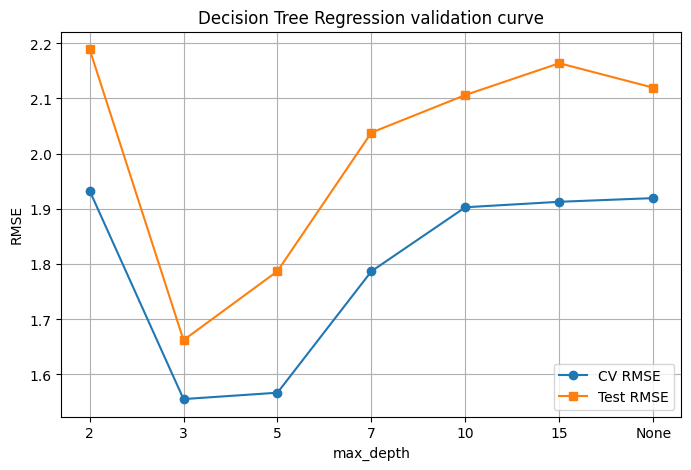

'\nNhận xét:\n- max_depth nhỏ làm cây đơn giản hơn, giúp giảm overfitting nhưng có thể underfit nếu cây quá nông.\n- max_depth lớn hoặc None cho phép cây học rất chi tiết, train score thường tốt nhưng test RMSE có thể tăng do học nhiễu.\n- Biểu đồ giúp chọn vùng độ sâu hợp lý trước khi dùng GridSearchCV để tìm tổ hợp siêu tham số tốt hơn.\n'

In [37]:
dt_depth_values = [2, 3, 5, 7, 10, 15, None]
dt_cv_rmse = []
dt_test_rmse = []

for depth in dt_depth_values:
    tree_reg = DecisionTreeRegressor(random_state=student_random_state, max_depth=depth)
    cv_scores = cross_val_score(
        tree_reg,
        X_student_train,
        y_student_train,
        cv=5,
        scoring='neg_root_mean_squared_error'
    )
    dt_cv_rmse.append(-cv_scores.mean())

    tree_reg.fit(X_student_train, y_student_train)
    test_pred = tree_reg.predict(X_student_test)
    dt_test_rmse.append(np.sqrt(mean_squared_error(y_student_test, test_pred)))

plt.figure(figsize=(8, 5))
plt.plot([str(v) for v in dt_depth_values], dt_cv_rmse, marker='o', label='CV RMSE')
plt.plot([str(v) for v in dt_depth_values], dt_test_rmse, marker='s', label='Test RMSE')
plt.xlabel('max_depth')
plt.ylabel('RMSE')
plt.title('Decision Tree Regression validation curve')
plt.legend()
plt.grid(True)
plt.show()

'''
Nhận xét:
- max_depth nhỏ làm cây đơn giản hơn, giúp giảm overfitting nhưng có thể underfit nếu cây quá nông.
- max_depth lớn hoặc None cho phép cây học rất chi tiết, train score thường tốt nhưng test RMSE có thể tăng do học nhiễu.
- Biểu đồ giúp chọn vùng độ sâu hợp lý trước khi dùng GridSearchCV để tìm tổ hợp siêu tham số tốt hơn.
'''


##### 2.7. Tìm kiếm siêu tham số bằng GridSearchCV

In [38]:
def grid_search_regression(algorithm, X_train, y_train, n_jobs, dict_param):
    if algorithm == 'decision-tree-regression':
        model = DecisionTreeRegressor(random_state=student_random_state)
    if algorithm == 'random-forest-regression':
        model = RandomForestRegressor(random_state=student_random_state)

    regressor = GridSearchCV(
        estimator=model,
        cv=5,
        param_grid=dict_param,
        n_jobs=n_jobs,
        scoring='neg_root_mean_squared_error'
    )
    regressor.fit(X_train, y_train)
    print('Best model:', regressor.best_estimator_)
    print('Best parameters:', regressor.best_params_)
    print('Best CV RMSE:', -regressor.best_score_)
    return regressor.best_estimator_

'''
Giải thích:
- Với bài toán hồi quy, GridSearchCV vẫn thử các tổ hợp siêu tham số như bài toán phân loại.
- Khác biệt chính là scoring dùng neg_root_mean_squared_error. sklearn quy ước điểm càng lớn càng tốt nên RMSE được đổi dấu âm; khi in kết quả cần lấy dấu trừ để đọc RMSE thật.
- Mục tiêu là chọn mô hình có RMSE trung bình qua cross-validation thấp nhất.
'''


'\nGiải thích:\n- Với bài toán hồi quy, GridSearchCV vẫn thử các tổ hợp siêu tham số như bài toán phân loại.\n- Khác biệt chính là scoring dùng neg_root_mean_squared_error. sklearn quy ước điểm càng lớn càng tốt nên RMSE được đổi dấu âm; khi in kết quả cần lấy dấu trừ để đọc RMSE thật.\n- Mục tiêu là chọn mô hình có RMSE trung bình qua cross-validation thấp nhất.\n'

In [39]:
dt_reg_param = {
    'max_depth': [2, 3, 5, 7, 10, 15, None],
    'min_samples_leaf': [1, 2, 5, 10, 20],
    'criterion': ['squared_error', 'absolute_error']
}

best_student_tree = grid_search_regression(
    'decision-tree-regression',
    X_student_train,
    y_student_train,
    n_jobs=1,
    dict_param=dt_reg_param
)

evaluate_regression(X_student_train, y_student_train, X_student_test, y_student_test, best_student_tree)

'''
Nhận xét Decision Tree Regression sau GridSearchCV:
- Kết quả tốt nhất thu được là DecisionTreeRegressor(max_depth=7, min_samples_leaf=5, criterion='squared_error').
- So với baseline, mô hình sau tuning không còn học thuộc hoàn toàn tập train. Train RMSE khoảng 1.04 và Test RMSE khoảng 1.80.
- Test R2 tăng lên khoảng 0.7904, tốt hơn Decision Tree baseline. Điều này cho thấy giới hạn độ sâu và số mẫu tối thiểu ở lá giúp giảm overfitting.
'''


Best model: DecisionTreeRegressor(max_depth=7, min_samples_leaf=5, random_state=42)
Best parameters: {'criterion': 'squared_error', 'max_depth': 7, 'min_samples_leaf': 5}
Best CV RMSE: 1.4930145807202613
Train MAE: 0.6303746606022056
Train RMSE: 1.0364800038383117
Train R2: 0.927227024307368
--------------------------------------------------
Test MAE: 0.9760992516255675
Test RMSE: 1.8001819864365534
Test R2: 0.7903956219274916


"\nNhận xét Decision Tree Regression sau GridSearchCV:\n- Kết quả tốt nhất thu được là DecisionTreeRegressor(max_depth=7, min_samples_leaf=5, criterion='squared_error').\n- So với baseline, mô hình sau tuning không còn học thuộc hoàn toàn tập train. Train RMSE khoảng 1.04 và Test RMSE khoảng 1.80.\n- Test R2 tăng lên khoảng 0.7904, tốt hơn Decision Tree baseline. Điều này cho thấy giới hạn độ sâu và số mẫu tối thiểu ở lá giúp giảm overfitting.\n"

In [40]:
rf_reg_param = {
    'max_depth': [10, 15, None],
    'min_samples_leaf': [1, 5],
    'max_features': [0.5, 1.0],
    'n_estimators': [100, 150]
}

best_student_forest = grid_search_regression(
    'random-forest-regression',
    X_student_train,
    y_student_train,
    n_jobs=1,
    dict_param=rf_reg_param
)

evaluate_regression(X_student_train, y_student_train, X_student_test, y_student_test, best_student_forest)

'''
Nhận xét Random Forest Regression sau GridSearchCV:
- Kết quả tốt nhất thu được là RandomForestRegressor(max_depth=15, max_features=1.0, min_samples_leaf=5, n_estimators=150).
- Test MAE khoảng 0.8852, Test RMSE khoảng 1.5874 và Test R2 khoảng 0.8370. Đây là kết quả tốt nhất trong các mô hình đã khảo sát.
- So với RF baseline, RMSE test giảm nhẹ và R2 test tăng nhẹ. Đồng thời train score bớt hoàn hảo hơn, cho thấy mô hình được regularize tốt hơn nhờ min_samples_leaf=5.
'''


Best model: RandomForestRegressor(max_depth=15, min_samples_leaf=5, n_estimators=150,
                      random_state=42)
Best parameters: {'max_depth': 15, 'max_features': 1.0, 'min_samples_leaf': 5, 'n_estimators': 150}
Best CV RMSE: 1.3885736653828846
Train MAE: 0.5982370152348918
Train RMSE: 1.026103953192509
Train R2: 0.928676770564119
--------------------------------------------------
Test MAE: 0.8851656982517966
Test RMSE: 1.5874267877471648
Test R2: 0.8370122607295534


'\nNhận xét Random Forest Regression sau GridSearchCV:\n- Kết quả tốt nhất thu được là RandomForestRegressor(max_depth=15, max_features=1.0, min_samples_leaf=5, n_estimators=150).\n- Test MAE khoảng 0.8852, Test RMSE khoảng 1.5874 và Test R2 khoảng 0.8370. Đây là kết quả tốt nhất trong các mô hình đã khảo sát.\n- So với RF baseline, RMSE test giảm nhẹ và R2 test tăng nhẹ. Đồng thời train score bớt hoàn hảo hơn, cho thấy mô hình được regularize tốt hơn nhờ min_samples_leaf=5.\n'

##### 2.8. Phân tích độ quan trọng của thuộc tính

Top feature importances for Random Forest Regression:
G2: 0.8802
absences: 0.0618
G1: 0.0078
subject_por: 0.0058
goout: 0.0056
studytime: 0.0047
age: 0.0042
sex_M: 0.0024
Walc: 0.0022
health: 0.0019
Medu: 0.0017
reason_home: 0.0017
failures: 0.0016
Fjob_services: 0.0014
famrel: 0.0014


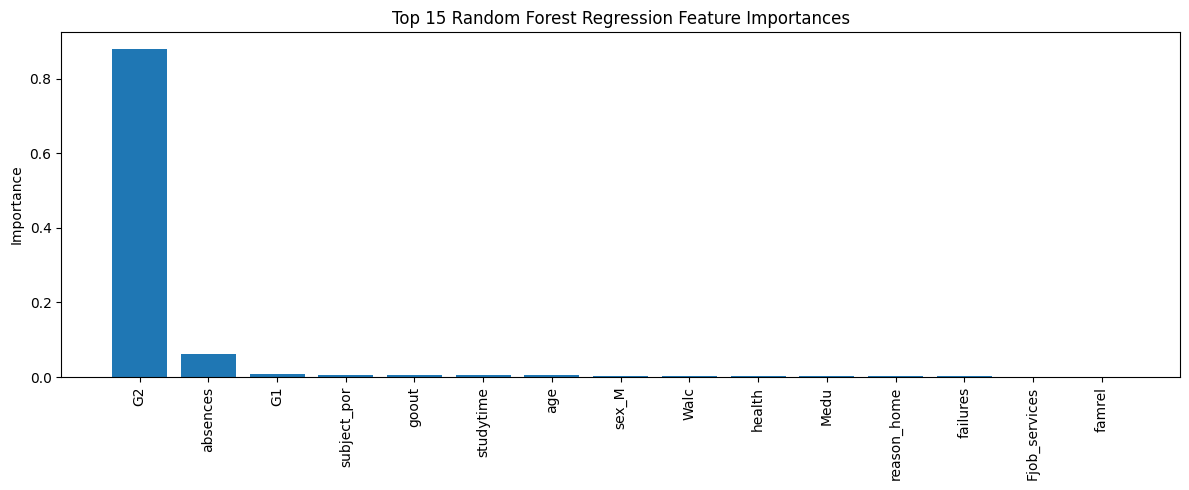

'\nNhận xét:\n- Thuộc tính quan trọng nhất là G2, chiếm phần lớn importance của mô hình. Điều này hợp lý vì G2 là điểm kỳ trước, có quan hệ trực tiếp với điểm cuối kỳ G3.\n- Các thuộc tính tiếp theo thường gồm absences, G1, goout, subject_por, studytime, age... nhưng mức độ quan trọng nhỏ hơn rất nhiều so với G2.\n- Kết quả cho thấy lịch sử điểm số là thông tin mạnh nhất để dự đoán G3; các yếu tố cá nhân và môi trường sống đóng vai trò bổ sung.\n'

In [41]:
student_importances = best_student_forest.feature_importances_
student_indices = np.argsort(student_importances)[::-1]

print('Top feature importances for Random Forest Regression:')
for idx in student_indices[:15]:
    print(f'{student_feature_names[idx]}: {student_importances[idx]:.4f}')

plt.figure(figsize=(12, 5))
plt.bar(
    range(15),
    student_importances[student_indices[:15]]
)
plt.xticks(
    range(15),
    [student_feature_names[idx] for idx in student_indices[:15]],
    rotation=90
)
plt.ylabel('Importance')
plt.title('Top 15 Random Forest Regression Feature Importances')
plt.tight_layout()
plt.show()

'''
Nhận xét:
- Thuộc tính quan trọng nhất là G2, chiếm phần lớn importance của mô hình. Điều này hợp lý vì G2 là điểm kỳ trước, có quan hệ trực tiếp với điểm cuối kỳ G3.
- Các thuộc tính tiếp theo thường gồm absences, G1, goout, subject_por, studytime, age... nhưng mức độ quan trọng nhỏ hơn rất nhiều so với G2.
- Kết quả cho thấy lịch sử điểm số là thông tin mạnh nhất để dự đoán G3; các yếu tố cá nhân và môi trường sống đóng vai trò bổ sung.
'''


##### 2.9. Thử nghiệm lựa chọn đặc trưng theo feature_importances_

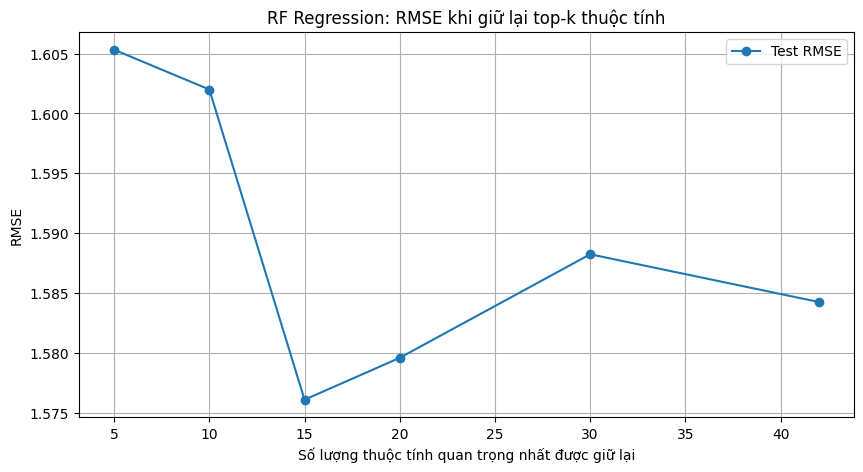

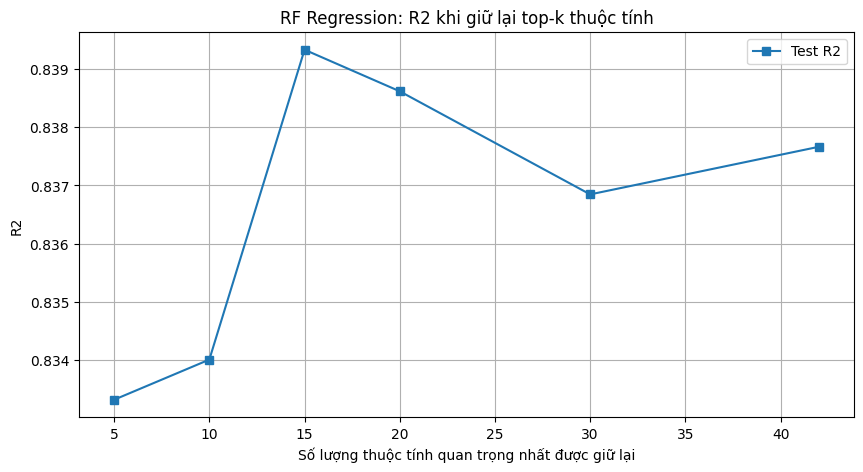

Feature selection results:
Top 5 features - Test RMSE: 1.6053, Test R2: 0.8333
Top 10 features - Test RMSE: 1.6020, Test R2: 0.8340
Top 15 features - Test RMSE: 1.5761, Test R2: 0.8393
Top 20 features - Test RMSE: 1.5796, Test R2: 0.8386
Top 30 features - Test RMSE: 1.5882, Test R2: 0.8368
Top 42 features - Test RMSE: 1.5843, Test R2: 0.8377


'\nNhận xét:\n- Thí nghiệm này giữ lại lần lượt top-k thuộc tính quan trọng nhất theo Random Forest và đánh giá lại mô hình.\n- Nếu chỉ giữ rất ít thuộc tính, mô hình phụ thuộc chủ yếu vào G2 và một vài biến mạnh khác nên vẫn có thể dự đoán khá tốt, nhưng có nguy cơ mất thông tin bổ sung.\n- Khi tăng số lượng thuộc tính, RMSE và R2 thường ổn định hơn. Nếu thêm quá nhiều thuộc tính ít quan trọng mà kết quả không cải thiện đáng kể, có thể chọn tập thuộc tính nhỏ hơn để mô hình gọn hơn.\n- Với bài toán này, G2 và G1 là các biến rất mạnh; tuy nhiên các thuộc tính hành vi/học tập khác vẫn có giá trị bổ sung cho Random Forest.\n'

In [42]:
top_k_values = [5, 10, 15, 20, 30, len(student_feature_names)]
feature_selection_rmse = []
feature_selection_r2 = []

for k in top_k_values:
    selected_features = student_indices[:k]
    X_train_selected = X_student_train.iloc[:, selected_features]
    X_test_selected = X_student_test.iloc[:, selected_features]

    model = RandomForestRegressor(
        random_state=student_random_state,
        max_depth=15,
        max_features=1.0,
        min_samples_leaf=5,
        n_estimators=150
    )
    model.fit(X_train_selected, y_student_train)
    pred = model.predict(X_test_selected)

    feature_selection_rmse.append(np.sqrt(mean_squared_error(y_student_test, pred)))
    feature_selection_r2.append(r2_score(y_student_test, pred))

plt.figure(figsize=(10, 5))
plt.plot(top_k_values, feature_selection_rmse, marker='o', label='Test RMSE')
plt.xlabel('Số lượng thuộc tính quan trọng nhất được giữ lại')
plt.ylabel('RMSE')
plt.title('RF Regression: RMSE khi giữ lại top-k thuộc tính')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(top_k_values, feature_selection_r2, marker='s', label='Test R2')
plt.xlabel('Số lượng thuộc tính quan trọng nhất được giữ lại')
plt.ylabel('R2')
plt.title('RF Regression: R2 khi giữ lại top-k thuộc tính')
plt.legend()
plt.grid(True)
plt.show()

print('Feature selection results:')
for k, rmse, r2 in zip(top_k_values, feature_selection_rmse, feature_selection_r2):
    print(f'Top {k} features - Test RMSE: {rmse:.4f}, Test R2: {r2:.4f}')

'''
Nhận xét:
- Thí nghiệm này giữ lại lần lượt top-k thuộc tính quan trọng nhất theo Random Forest và đánh giá lại mô hình.
- Nếu chỉ giữ rất ít thuộc tính, mô hình phụ thuộc chủ yếu vào G2 và một vài biến mạnh khác nên vẫn có thể dự đoán khá tốt, nhưng có nguy cơ mất thông tin bổ sung.
- Khi tăng số lượng thuộc tính, RMSE và R2 thường ổn định hơn. Nếu thêm quá nhiều thuộc tính ít quan trọng mà kết quả không cải thiện đáng kể, có thể chọn tập thuộc tính nhỏ hơn để mô hình gọn hơn.
- Với bài toán này, G2 và G1 là các biến rất mạnh; tuy nhiên các thuộc tính hành vi/học tập khác vẫn có giá trị bổ sung cho Random Forest.
'''


##### Kết luận Bài toán 2
- Bài toán dự đoán `G3` là bài toán hồi quy, do đó dùng `DecisionTreeRegressor` và `RandomForestRegressor` thay vì classifier.
- Decision Tree baseline dễ overfit vì cây có thể học thuộc tập train. Sau khi giới hạn `max_depth` và `min_samples_leaf`, kết quả test cải thiện rõ hơn.
- Random Forest Regression cho kết quả tốt nhất trong các mô hình đã khảo sát, với Test RMSE khoảng `1.59` và Test R2 khoảng `0.84`.
- Thuộc tính quan trọng nhất là `G2`, tiếp theo là một số biến như `absences`, `G1`, `goout`, `subject_por`, `studytime`. Điều này phù hợp với trực giác: điểm kỳ trước là yếu tố dự báo mạnh nhất cho điểm cuối kỳ.